# Causal-TS API Reference

A comprehensive API reference for the `causal-ts` framework.

| # | Module | Description |
|---|--------|-------------|
| 1 | [CI Tests](#1-conditional-independence-tests) | KCIGPU, RCOTGPU, PartialCorr, ParCorrGPU, CMIKNN, CMIknnGPU, GCMIGPU, **SplitKCIGPU**, **DFCITGPU**, **SigKCIGPU**, **StratifiedCIT**, **CMIknnMixedGPU** |
| 2 | [CDNOTS](#2-cdnots) | Constraint-based causal discovery for nonstationary time series |
| 3 | [CEDAR](#3-cedar) | Scalable discovery via minimum-lag selection |
| 4 | [GRACE](#4-grace) | Neural gated refinement with L0 regularization |
| 5 | [LUCID](#5-lucid) | Latent-confounder correction: regime-adaptive deconfounding of a discovered graph |
| 6 | [Plotting](#6-plotting) | Graph visualization, comparison, metrics, p-values |
| 7 | [Synthetic Data](#7-synthetic-data) | Random SCP graph generation for benchmarking |
| 8 | [Evaluation](#8-evaluation) | `evaluate_graph` metrics |
| 9 | [Effect Estimation (DoWhy)](#9-effect-estimation) | Effect estimation, counterfactuals, root cause analysis (optional) |
| 10 | [Tigramite Effects](#10-tigramite-effects) | TigramiteEffects, pathwise_effects |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import causalts.plotting as tp
from causalts.ci_tests import KCIGPU
from causalts.ci_tests import RCOTGPU
from causalts.ci_tests import PartialCorr
from causalts.ci_tests import ParCorrGPU
from causalts.ci_tests import CMIKNN
from causalts.ci_tests import CMIknnGPU
from causalts.ci_tests import GCMIGPU
from causalts.ci_tests import SplitKCIGPU
from causalts.ci_tests import DFCITGPU
from causalts.ci_tests import SigKCIGPU
from causalts import run_cdnots, run_cdnots_plus, make_c_array

from causalts.cedar import run_cedar, Cedar
from causalts.grace import run_cdnots_gated
from causalts.effects.tigramite_effects import TigramiteEffects, pathwise_effects
from causalts.utils import evaluate_graph
from causalts.synthetic_data.synthetic_datasets import SCPGraphGenerator

%matplotlib inline


<a id="setup-shared-datasets"></a>
## Setup: Shared datasets

We generate two datasets used throughout this guide.

In [2]:
# --- Dataset A: 5-var nonstationary (with time node C) ---
np.random.seed(32)
T_a, maxlag_a = 300, 2
ts = np.random.randn(T_a + maxlag_a, 5)
for t in range(maxlag_a, T_a + maxlag_a):
    ts[t, 0] += 0.6 * ts[t-1, 0] + 0.3 * ts[t-2, 1] + 3 * ((t - maxlag_a)**2 / 100000)
    ts[t, 1] += 0.8 * ts[t-1, 1] + 1.5 * ((t - maxlag_a)**2 / 100000)
    ts[t, 2] += 0.6 * ts[t-1, 2] + np.sin((t - maxlag_a) / 20)
    ts[t, 3] += 0.5 * ts[t-1, 3] + 0.7 * ts[t-2, 2]
    ts[t, 4] += 0.5 * ts[t-1, 4] + 0.3 * ts[t-1, 3]

df_a = pd.DataFrame(ts[maxlag_a:], columns=[f"X{i}" for i in range(5)])
names_a = df_a.columns.tolist()

true_a = np.zeros((6, 6, maxlag_a + 1))  # 5 vars + C
true_a[0, 0, 1] = 1; true_a[1, 0, 2] = 1; true_a[5, 0, 0] = 1
true_a[1, 1, 1] = 1; true_a[5, 1, 0] = 1
true_a[2, 2, 1] = 1; true_a[5, 2, 0] = 1
true_a[3, 3, 1] = 1; true_a[2, 3, 2] = 1
true_a[4, 4, 1] = 1; true_a[3, 4, 1] = 1

# --- Dataset B: 11-var signaling network (stationary, no C) ---
np.random.seed(42)
T_b, maxlag_b = 300, 3
x = np.random.randn(T_b + maxlag_b, 11)
for t in range(maxlag_b, T_b + maxlag_b):
    x[t, 0] += 0.9 * x[t-1, 0]
    x[t, 1] += 0.6 * x[t-1, 1] + 0.5 * x[t-2, 0]
    x[t, 2] += 0.4 * x[t-1, 2] + 0.4 * x[t-3, 0] + 0.3 * x[t-1, 1]
    x[t, 3] += 0.25 * x[t-1, 3]
    x[t, 4] += 0.25 * x[t-1, 4] - 0.25 * x[t-1, 3]
    x[t, 5] += 0.25 * x[t-1, 5] + 0.50 * x[t-2, 3] - 0.50 * x[t-1, 4]
    x[t, 6] += 0.30 * x[t-1, 6] - 0.25 * x[t-3, 3] + 0.25 * x[t-3, 4]
    x[t, 7] += 0.40 * x[t-1, 7] + 0.35 * x[t-1, 3] + 0.25 * x[t-2, 4]
    x[t, 8] += 0.50 * x[t-1, 8] - 0.5 * x[t-1, 3] + 0.25 * x[t-1, 4] + 0.6 * x[t-2, 7]
    x[t, 9] += 0.6 * x[t-1, 9] + 0.45 * x[t-1, 4] - 0.35 * x[t-2, 8]
    x[t, 10] += 0.7 * x[t-1, 10] - 0.25 * x[t-1, 4] + 0.25 * x[t-2, 9]

names_b = ["Plcg", "Pip3", "Pip2", "PKC", "PKA", "P38", "Jnk", "Raf", "Mek", "Erk", "Akt"]
df_b = pd.DataFrame(x[maxlag_b:], columns=names_b)

true_b = np.zeros((11, 11, maxlag_b + 1))
edges_b = [
    (0,0,1), (0,1,2), (1,1,1), (0,2,3), (1,2,1), (2,2,1),
    (3,3,1), (3,4,1), (4,4,1), (3,5,2), (4,5,1), (5,5,1),
    (3,6,3), (4,6,3), (6,6,1), (3,7,1), (4,7,2), (7,7,1),
    (3,8,1), (4,8,1), (7,8,2), (8,8,1), (4,9,1), (8,9,2),
    (9,9,1), (4,10,1), (9,10,2), (10,10,1),
]
for i, j, tau in edges_b:
    true_b[i, j, tau] = 1

print(f"Dataset A: {df_a.shape}, {len(names_a)} vars + C, max_lag={maxlag_a}")
print(f"Dataset B: {df_b.shape}, {len(names_b)} vars, max_lag={maxlag_b}")

Dataset A: (300, 5), 5 vars + C, max_lag=2
Dataset B: (300, 11), 11 vars, max_lag=3


---

<a id="1-conditional-independence-tests"></a>
# 1. Conditional Independence Tests

All CI tests share a common interface: `test(X, Y, condition_set)` returning `(p_value, statistic)`.  
Run `causal-ts ci-test-info` in the CLI for an interactive selection guide with benchmark numbers.

| Test | Class | Type | Speed | Best for |
|------|-------|------|-------|----------|
| Partial Correlation | `PartialCorr` | Linear | ⚡⚡⚡ | Linear, CPU-only |
| Partial Correlation GPU | `ParCorrGPU` | Linear | ⚡⚡⚡ | Linear, GPU-batched |
| Gaussian Copula | `GCMIGPU` | Monotone nonlinear | ⚡⚡⚡ | Fast analytic, mild nonlinearity |
| Randomized CoT | `RCOTGPU` | Nonlinear | ⚡⚡ | Large T (>2000), fast |
| **Split KCI** | **`SplitKCIGPU`** | **Nonlinear** | **⚡⚡** | **Nonlinear, bias-controlled** |
| Kernel CI | `KCIGPU` | Nonlinear | ⚡ | General nonlinear, high collinearity |
| **DFCIT** | **`DFCITGPU`** | **Distribution-free** | **⚡** | **Highest recall, T<500** |
| CMI k-NN GPU | `CMIknnGPU` | Nonlinear | ⚡ | Accurate nonlinear, T<400 |
| CMI k-NN CPU | `CMIKNN` | Nonlinear | 🐌 | Reference / no GPU |
| **Signature Kernel** | **`SigKCIGPU`** | **Path-space** | **⚡⚡** | **Stochastic processes / SDEs** |

**Empirical benchmarks:** See the [CI Test Comparison](examples/ci_test_comparison.html) notebook for full benchmarks across datasets and sample sizes. Key findings:
- **Linear data:** `ParCorrGPU` achieves near-optimal F1 at essentially zero runtime.
- **Nonlinear data:** `DFCITGPU` is strongest with CDNOTS; `SplitKCIGPU` is best with CDNOTS+ and 5–8× faster.
- **Speed:** `ParCorrGPU` and `GCMIGPU` are instant; `SplitKCIGPU` and `RCOTGPU` are fast; `KCIGPU` and `CMIknnGPU` are slow.

<a id="kcigpu"></a>
## KCIGPU

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
<em>class</em> causalts.ci_tests.<strong>KCIGPU</strong>(<em>data, device=None, approx='hbe', cache_dir=None, data_hash=None</em>)
</div>

GPU-accelerated Kernel-based Conditional Independence Test.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>data</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Input data matrix (T, d).</dd>
<dt><strong>device</strong> : <em>str, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'cuda'</code>, <code>'cpu'</code>, or <code>None</code> (auto-detect).</dd>
<dt><strong>approx</strong> : <em>str, default='hbe'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">P-value approximation: <code>'hbe'</code> (Hall-Buckley-Eagleson, 3-moment), <code>'gamma'</code> (Satterthwaite-Welch, 2-moment).</dd>
<dt><strong>cache_dir</strong> : <em>str, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Directory for caching p-values.</dd>
<dt><strong>data_hash</strong> : <em>str, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Unique identifier for cache key.</dd>
</dl>
</div>

---

<a id="rcotgpu"></a>
## RCOTGPU

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
<em>class</em> causalts.ci_tests.<strong>RCOTGPU</strong>(<em>data, num_f=25, num_f2=25, approx='hbe', nperm=200, n_avg=5, device=None, seed=None</em>)
</div>

GPU-accelerated Randomized Conditional Correlation Test using Random Fourier Features.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>data</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Input data matrix (T, d).</dd>
<dt><strong>num_f</strong> : <em>int, default=25</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Random Fourier features for the conditioning set Z.</dd>
<dt><strong>num_f2</strong> : <em>int, default=25</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Random Fourier features for X and Y. Higher values reduce per-draw variance.</dd>
<dt><strong>nperm</strong> : <em>int, default=200</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Permutations for null distribution (only when <code>approx='perm'</code>).</dd>
<dt><strong>n_avg</strong> : <em>int, default=5</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Independent RFF draws whose p-values are combined via harmonic mean (Wilson 2019). Reduces RFF randomness variance at small T. Set to 1 for original single-draw behaviour.</dd>
<dt><strong>device</strong> : <em>str, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'cuda'</code>, <code>'cpu'</code>, or <code>None</code> (auto-detect).</dd>
</dl>
</div>

---

<a id="partialcorr"></a>
## PartialCorr

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
<em>class</em> causalts.ci_tests.<strong>PartialCorr</strong>(<em>data, cache_dir=None, data_hash=None</em>)
</div>

Linear partial correlation test. Fastest CPU option, appropriate when dependencies are linear.

---

<a id="parcorrgpu"></a>
## ParCorrGPU

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
<em>class</em> causalts.ci_tests.<strong>ParCorrGPU</strong>(<em>data, device=None, enable_batching=True, cache_dir=None, data_hash=None</em>)
</div>

GPU-accelerated partial correlation test with batched evaluation. Computes partial correlation via precision matrix inversion on GPU. The `batch_test()` method evaluates thousands of CI tests in a single GPU kernel launch.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>data</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Input data matrix (T, d).</dd>
<dt><strong>device</strong> : <em>str, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'cuda'</code>, <code>'mps'</code>, <code>'cpu'</code>, or <code>None</code> (auto-detect).</dd>
<dt><strong>enable_batching</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Enable batched GPU evaluation.</dd>
<dt><strong>cache_dir</strong> : <em>str, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Directory for caching p-values.</dd>
<dt><strong>data_hash</strong> : <em>str, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Unique identifier for cache key.</dd>
</dl>
</div>

**Key method:** `batch_test(tests, max_batch_size=2048)` — evaluate a list of `(X, Y, condition_set)` tuples in vectorized GPU operations, grouped by conditioning set size.

> **Note:** `ParCorrGPU` supports CUDA, MPS (Apple Silicon), and CPU. GRACE auto-selects `ParCorrGPU` when a GPU is available.

---

<a id="cmiknn"></a>
## CMIKNN

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
<em>class</em> causalts.ci_tests.<strong>CMIKNN</strong>(<em>data, k=0.2, workers=1, early_stop=True, sig_samples=500, target_quantile=0.05</em>)
</div>

Conditional mutual information test based on k-nearest neighbor density estimation (Frenzel-Pompe 2007). CPU-only reference implementation.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>data</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Input data matrix (T, d).</dd>
<dt><strong>k</strong> : <em>float, default=0.2</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">k-NN fraction (or int for fixed k). See knn tuning notes below.</dd>
<dt><strong>workers</strong> : <em>int, default=1</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Number of parallel workers for cKDTree queries.</dd>
<dt><strong>early_stop</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Stop shuffle early if significance is clear.</dd>
<dt><strong>sig_samples</strong> : <em>int, default=500</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Maximum shuffle samples for null distribution. Early stopping means most tests use far fewer.</dd>
</dl>
</div>

---

<a id="cmiknn-gpu"></a>
## CMIknnGPU

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
<em>class</em> causalts.ci_tests.<strong>CMIknnGPU</strong>(<em>data, device=None, k=0.2, shuffle_neighbors=5, sig_samples=500, transform='ranks', early_stop=True, target_quantile=0.05, chunk_size=4096, sig_blocklength=3</em>)
</div>

GPU-accelerated CMI estimator using `torch.cdist` with Chebyshev distance instead of scipy cKDTree. Same algorithm as `CMIKNN` but 3–9x faster. Uses float32 on CUDA for throughput; float64 on CPU for accuracy.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>data</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Input data matrix (T, d).</dd>
<dt><strong>device</strong> : <em>str, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'cuda'</code> or <code>'cpu'</code>. MPS not supported (no float64). Auto-detects CUDA.</dd>
<dt><strong>k</strong> : <em>float, default=0.2</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">k-NN fraction of T. Recommended: 0.15–0.20 for T=300–1000.</dd>
<dt><strong>shuffle_neighbors</strong> : <em>int, default=5</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Neighbors in Z-space for shuffle surrogates.</dd>
<dt><strong>sig_samples</strong> : <em>int, default=500</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Maximum shuffle samples. Early stopping reduces actual samples substantially on clear tests.</dd>
<dt><strong>early_stop</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Stop shuffle early if significance is clear (saves ~80% of samples on strong tests).</dd>
<dt><strong>chunk_size</strong> : <em>int, default=4096</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Chunk size for distance computation when T exceeds memory.</dd>
<dt><strong>sig_blocklength</strong> : <em>int, default=3</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Block length for block-shuffle of unconditional (Z-empty) tests. Preserves short-range temporal autocorrelation in the null distribution, matching the tigramite CMIknn behaviour.</dd>
</dl>
</div>

> **knn tuning:** The knn fraction controls false positive rate. Too small → false positives on independent pairs. Recommended values by sample size:
> - T ≈ 100: knn=0.15 (k≈14)
> - T ≈ 300: knn=0.15–0.20 (k≈44–59)
> - T ≈ 500: k=0.20 (k≈99)
> - T ≈ 1000: k=0.20 (k≈199)

---

<a id="gcmi-gpu"></a>
## GCMIGPU

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
<em>class</em> causalts.ci_tests.<strong>GCMIGPU</strong>(<em>data, device=None, jitter=1e-10</em>)
</div>

Gaussian Copula Mutual Information — a fast analytic CI test. Rank-transforms each variable to Gaussian marginals, then computes CMI as the partial correlation of the copula-normalized data. **No shuffle test**: uses Student's t-distribution for p-values directly.

**What it detects:** Linear dependencies and all monotone nonlinear relationships (any transformation preserving rank order, e.g. quadratic, logarithmic, sigmoid). Does NOT detect non-monotone relationships (oscillatory, U-shaped, XOR-type).

**Speed:** O(T log T) sort + O(d²) matrix inversion. Typically 100–1000x faster than CMIknnGPU.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>data</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Input data matrix (T, d).</dd>
<dt><strong>device</strong> : <em>str, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'cuda'</code>, <code>'mps'</code>, <code>'cpu'</code>, or <code>None</code> (auto-detect).</dd>
<dt><strong>jitter</strong> : <em>float, default=1e-10</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Small noise added before ranking to break ties in degenerate data.</dd>
</dl>
</div>

In [3]:
# Collider bias demo: X3 -> X5 <- X4
np.random.seed(42)
demo_data = np.random.randn(100, 5)
demo_data = np.hstack((demo_data, (demo_data[:, 2]**2 + demo_data[:, 3]).reshape(-1, 1)))

kci = KCIGPU(demo_data, device="cpu")
print("Conditioned on collider (spurious dependence):")
print(f"  p-value = {kci(X=2, Y=3, condition_set=[5])[0]:.4f}")
print("Unconditional (true independence):")
print(f"  p-value = {kci(X=2, Y=3, condition_set=[])[0]:.4f}")

Conditioned on collider (spurious dependence):
  p-value = 0.0217
Unconditional (true independence):
  p-value = 0.7606


In [4]:
# Compare all CI tests on the same pair
tests = {
    "KCIGPU":      KCIGPU(demo_data, device="cpu"),
    "RCOTGPU":     RCOTGPU(demo_data, device="cpu"),
    "PartialCorr": PartialCorr(demo_data),
    "GCMIGPU":     GCMIGPU(demo_data, device="cpu"),
    "SplitKCIGPU": SplitKCIGPU(demo_data, device="cpu"),
    "DFCITGPU":    DFCITGPU(demo_data, device="cpu", n_perm=200),
    "SigKCIGPU":   SigKCIGPU(demo_data, device="cpu", time_delay_dim=2),
    "CMIKNN":      CMIKNN(demo_data, k=0.2, early_stop=True),
    "CMIknnGPU":   CMIknnGPU(demo_data, device="cpu", k=0.2, early_stop=True),
}

print(f"{'Test':<14} {'Time':>8} {'P-value':>10} {'Statistic':>12}")
print("-" * 48)
for name, test in tests.items():
    t0 = time.time()
    p, s = test(X=0, Y=1, condition_set=[2, 3])
    dt = time.time() - t0
    print(f"{name:<14} {dt:>7.4f}s {p:>10.4f} {s:>12.3f}")

Test               Time    P-value    Statistic
------------------------------------------------
KCIGPU          0.0031s     0.0598       15.897
RCOTGPU         0.1183s     0.1124      607.558
PartialCorr     0.0005s     0.0991       -0.168
GCMIGPU         0.0005s     0.1106        0.013
SplitKCIGPU     0.0026s     0.1208        0.010
DFCITGPU        0.0026s     0.5200        0.001
SigKCIGPU       0.0028s     0.1833        1.719
CMIKNN          1.1797s     0.6500        0.029
CMIknnGPU       0.0218s     0.5854        0.029


---

<a id="stratifiedcit"></a>
## StratifiedCIT

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
<em>class</em> causalts.ci_tests.<strong>StratifiedCIT</strong>(<em>data, discrete_cols, inner_cit, max_strata=8, min_stratum=30</em>)
</div>

Wrapper for handling **discrete conditioning variables** in CI tests. Partitions the sample into strata defined by the joint discrete values in Z, runs the inner CI test on continuous Z within each stratum, and combines p-values via Fisher's method.

Falls back to the inner test directly when no discrete columns appear in the conditioning set, when the number of strata exceeds `max_strata`, or when any stratum has fewer than `min_stratum` observations.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>data</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Lag-embedded data matrix (T, d). Typically a placeholder at construction — CDNOTS sets it after lag-embedding.</dd>
<dt><strong>discrete_cols</strong> : <em>list[int]</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Column indices (in the lag-embedded matrix) that are discrete. Use <code>compute_discrete_indices()</code> to convert from original column names, or let <code>run_cdnots</code> auto-detect and set these.</dd>
<dt><strong>inner_cit</strong> : <em>CIT_Base instance</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Any CI test (ParCorrGPU, KCIGPU, DFCITGPU, etc.) used within each stratum.</dd>
<dt><strong>max_strata</strong> : <em>int, default=8</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Maximum number of strata before falling back to the inner test on full data. Prevents exponential explosion with many binary conditioning columns.</dd>
<dt><strong>min_stratum</strong> : <em>int, default=30</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Minimum rows per stratum. If any stratum is too small, falls back to inner test.</dd>
</dl>
</div>

**Key helper:**
```python
from causalts.ci_tests.stratified_cit import compute_discrete_indices
indices = compute_discrete_indices(["Regime", "State"], df, lags=[0,1,2,3], include_C=True)
```

> **Note:** You rarely need to construct `StratifiedCIT` manually — `run_cdnots` auto-detects discrete columns and wraps your CI test automatically. Pass `discrete_cols=[]` to disable.

---

<a id="cmiknn-mixed-gpu"></a>
## CMIknnMixedGPU

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
<em>class</em> causalts.ci_tests.<strong>CMIknnMixedGPU</strong>(<em>data, discrete_cols, device=None, k=0.2, sig_samples=500, ...</em>)
</div>

GPU CMI k-NN with the **MSinf distance strategy** (Popescu, Gerhardus, Runge 2023). Pairs where any discrete dimension disagrees get infinite distance — they are never considered neighbors. Within same-discrete-value observations, standard Chebyshev distance over continuous dimensions is used.

Inherits all parameters from `CMIknnGPU`. Use when you want a nonparametric CI test that natively handles mixed data without the two-stage Fisher combination approach of `StratifiedCIT`.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Additional parameter:**

<dl style="margin-left: 8px;">
<dt><strong>discrete_cols</strong> : <em>list[int]</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Column indices (in the lag-embedded matrix) that are discrete. Same as <code>StratifiedCIT</code>.</dd>
</dl>
</div>

> **When to use:** For datasets with nonlinear relationships between continuous variables where stratification+ParCorr would miss nonlinearities. Slower than `StratifiedCIT+ParCorr` but more general. Needs T≥300 to be competitive.

---

<a id="auto-detection"></a>
## Auto-Detection of Discrete Columns

`run_cdnots` automatically detects discrete columns in the input DataFrame using a simple heuristic:

1. All non-NaN values are integer-valued (`x == round(x)`)
2. Number of unique values < `min(20, sqrt(T))`

If detected and the CI test is not already discrete-aware (`StratifiedCIT` or `CMIknnMixedGPU`), it wraps the test in `StratifiedCIT` and issues a `UserWarning`.

**Control:**
- `discrete_cols=None` (default) — auto-detect
- `discrete_cols=["B1", "B2"]` — user specifies which columns are discrete
- `discrete_cols=[]` — explicitly opt-out, treat all columns as continuous

---

<a id="splitkci-gpu"></a>
## SplitKCIGPU

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
<em>class</em> causalts.ci_tests.<strong>SplitKCIGPU</strong>(<em>data, device=None, split_ratio=0.5, ridge_lambda=1e-3, pval_method='gamma', n_bootstrap=500, use_all_data=False, seed=42</em>)
</div>

Bias-controlled kernel CI test. Splits data into train/test halves: fits kernel ridge regression (KRR) on train to learn E[K_Y|Z] and E[K_X|Z], then computes HSIC on the CME-centered residual kernels on the test set. Eliminates KRR overfitting bias at the cost of using only n/2 points for the HSIC test.

**10–20× faster than KCIGPU** at the same T. Matches KCI on nonlinear data. Performance improves with larger T where the test half has enough power.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>data</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Input data matrix (T, d). Pass placeholder at construction; CDNOTS overwrites before each test.</dd>
<dt><strong>device</strong> : <em>str, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'cuda'</code>, <code>'mps'</code>, <code>'cpu'</code>, or <code>None</code> (auto-detect).</dd>
<dt><strong>split_ratio</strong> : <em>float, default=0.5</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Fraction used as test set. 0.5 is optimal empirically — smaller reduces training quality; larger reduces test power.</dd>
<dt><strong>ridge_lambda</strong> : <em>float, default=1e-3</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Starting regularisation for KRR. LOO cross-validation selects the best value from a grid, so this is rarely critical.</dd>
<dt><strong>pval_method</strong> : <em>str, default='gamma'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'gamma'</code> (Satterthwaite-Welch, fast) or <code>'wild_bootstrap'</code> (Rademacher, 2× slower, same accuracy).</dd>
<dt><strong>n_bootstrap</strong> : <em>int, default=500</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Bootstrap samples (only used when <code>pval_method='wild_bootstrap'</code>).</dd>
<dt><strong>bandwidth</strong> : <em>str, default='median'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">RBF kernel bandwidth. <code>'median'</code> uses the median heuristic.</dd>
<dt><strong>use_all_data</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Fit two KRR models (one per half), cross-predict on all data. Eliminates split bias while using all T points, but the additional estimation noise typically hurts F1 in practice.</dd>
</dl>
</div>

> **Limitation:** Uses n/2 points for testing → needs more data than KCI for the same power. Split variance can cause non-monotone F1 vs T on weak signals. Struggles with |corr|>0.9 in conditioning sets (KRR noisy on half data).

---

<a id="dfcit-gpu"></a>
## DFCITGPU

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
<em>class</em> causalts.ci_tests.<strong>DFCITGPU</strong>(<em>data, device=None, n_perm=500, bandwidth='silverman', alpha=0.05, early_stop=True, whiten_z=False, residualize=False, seed=42, sig_blocklength='auto'</em>)
</div>

Distribution-Free Conditional Independence Test (Cai, Li, Zhang, JMLR 2022). Estimates conditional CDFs via Nadaraya-Watson kernel smoothing, builds an exponential kernel matrix from CDF values, then tests independence using a batched permutation test with early stopping.

**Highest recall on nonlinear data**. Fully distribution-free — detects any dependency, not just monotone. O(T²) per permutation.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>data</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Input data matrix (T, d).</dd>
<dt><strong>device</strong> : <em>str, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'cuda'</code>, <code>'mps'</code>, <code>'cpu'</code>, or <code>None</code>.</dd>
<dt><strong>n_perm</strong> : <em>int, default=500</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Maximum permutations. Early stopping reduces this substantially on clear tests.</dd>
<dt><strong>bandwidth</strong> : <em>str or float, default='silverman'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">NW kernel bandwidth. <code>'silverman'</code> uses Silverman's rule: h = 1.06·σ·n^{-1/5}. Pass a float to fix it.</dd>
<dt><strong>alpha</strong> : <em>float, default=0.05</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Target significance level (used by early stopping).</dd>
<dt><strong>early_stop</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Stop permutations when the null z-score exceeds 5. Saves ~60–80% of permutations on clear-cut tests.</dd>
<dt><strong>whiten_z</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">PCA-whiten Z before bandwidth computation. Reduces collinearity in conditioning set. Disabled by default as it can hurt recall on nonlinear data.</dd>
<dt><strong>residualize</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">OLS-residualize X and Y against Z, then run unconditional test on residuals. Effective only for purely linear Z effects; destroys nonlinear signal so disabled by default.</dd>
<dt><strong>sig_blocklength</strong> : <em>int or 'auto', default='auto'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Block length for unconditional (Z-empty) permutation test. <code>'auto'</code> computes <code>max(3, int(T**0.5))</code>, which gives ≈17 at T=300. Block shuffle preserves short-range autocorrelation and avoids 8× type-I error inflation on AR(1) data compared to random permutation. Conditional tests (non-empty Z) use OLS residuals and always use random permutation.</dd>
</dl>
</div>

> **Limitation:** At large T with near-collinear conditioning sets (|corr|>0.9), Silverman's bandwidth narrows and the NW estimator creates false positives. Use KCI in that regime.

---

<a id="sigkci-gpu"></a>
## SigKCIGPU

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
<em>class</em> causalts.ci_tests.<strong>SigKCIGPU</strong>(<em>data, device=None, sigma='median', dyadic_order=0, path_transform='time_delay', time_delay_dim=3, approx='hbe', nperms=200, lamda=0.001, seed=42</em>)
</div>

Signature Kernel Conditional Independence Test (Manten, Casolo et al., arXiv:2402.18477). Embeds each observation as a short path (time-delay window), computes signature kernels between paths via a vectorized Goursat PDE solver, then applies the KCI framework to the resulting kernel matrices.

Designed for **stochastic processes and SDEs** where causal mechanisms depend on the trajectory of a variable, not just its pointwise value. Fast after vectorisation (~0.002–0.008s/test on CPU).

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>data</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Input data matrix (T, d).</dd>
<dt><strong>device</strong> : <em>str, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'cuda'</code>, <code>'mps'</code>, <code>'cpu'</code>, or <code>None</code>.</dd>
<dt><strong>sigma</strong> : <em>float or str, default='median'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Bandwidth for the inner-product kernel in the PDE. <code>'median'</code> uses the median heuristic. Use a fixed float (e.g. 2.0) to reduce sensitivity.</dd>
<dt><strong>dyadic_order</strong> : <em>int, default=0</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">PDE solver refinement level. 0 = raw increments (fast). Higher values linearly interpolate path increments for more accurate signature computation but increase runtime as 2^dyadic_order.</dd>
<dt><strong>time_delay_dim</strong> : <em>int, default=3</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Window size for path embedding. Each observation becomes a path of this many consecutive time points. 3 captures short-range dynamics; 2 is the minimum meaningful path.</dd>
<dt><strong>approx</strong> : <em>str, default='hbe'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">P-value approximation: <code>'hbe'</code> (Hall-Buckley-Eagleson, 3-moment), <code>'gamma'</code> (SW, 2-moment), or <code>'perm'</code> (permutation).</dd>
<dt><strong>nperms</strong> : <em>int, default=200</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Permutations (only for <code>approx='perm'</code>).</dd>
<dt><strong>lamda</strong> : <em>float, default=0.001</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Regularisation for KCI matrix inversion. Increased automatically if singular.</dd>
</dl>
</div>

> **Note:** If the `sigkernel` library is installed, the Gram matrix computation is delegated to its CUDA-accelerated PDE solver. Otherwise the built-in vectorized PyTorch solver is used (comparable speed on CPU).

<a id="2-cdnots"></a>
# 2. CDNOTS

Constraint-based causal discovery for nonstationary time series. Introduces an explicit time node C to capture distributional shifts.

```python
from causalts import run_cdnots, run_cdnots_plus
```

<a id="run_cdnots"></a>
## `run_cdnots`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.<strong>run_cdnots</strong>(<em>df, indep_test, num_lags=1, lag_list=None, include_C=True, c_preset=None, c_array=None, alpha=0.05, stable=True, max_degree=None, priority=2, verbose=False, show_progress=False, impute=None, impute_kwargs=None, discrete_cols=None, background_knowledge=None, lag_verify=False, alpha_lv=None, max_combinations=20, return_pvals=False</em>)
</div>

Run the full CDNOTS pipeline: skeleton discovery, collider orientation, Meek rules, and phase 3 nonstationarity-based orientation. Returns a single `CdnotsResult` object.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Key parameters:**

<dl style="margin-left: 8px;">
<dt><strong>df</strong> : <em>DataFrame</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Time series data (T × d).</dd>
<dt><strong>indep_test</strong> : <em>CI test instance</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Any CI test (KCIGPU, PartialCorr, SplitKCIGPU, etc.).</dd>
<dt><strong>num_lags</strong> : <em>int, default=1</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Maximum lag. Ignored when <code>lag_list</code> is provided.</dd>
<dt><strong>include_C</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Add the nonstationarity node C. Set to <code>False</code> for stationary data.</dd>
<dt><strong>c_preset</strong> : <em>str, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">C basis preset: <code>'linear'</code> (default), <code>'linear+quad'</code>, <code>'linear+sin'</code>, <code>'linear+exp'</code>, <code>'step'</code>, <code>'step+linear'</code>.</dd>
<dt><strong>c_array</strong> : <em>ndarray (T, k), default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Custom C basis (overrides <code>c_preset</code>). Use <code>make_c_array(T, preset)</code> or supply any (T, k) array.</dd>
<dt><strong>alpha</strong> : <em>float, default=0.05</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Significance level for CI tests.</dd>
<dt><strong>discrete_cols</strong> : <em>list[str] or None, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Discrete column names (auto-detected if None). Pass <code>[]</code> to opt out.</dd>
</dl>

**Returns:** `CdnotsResult` — self-contained result with:
- `.cg_tig` — 3D graph array `(d, d, tau+1)`, `graph[i,j,tau]=1` means `i(t-tau)→j(t)`
- `.pvalue_matrix` — p-values from skeleton discovery
- `.var_names`, `.num_lags`, `.include_C`, `.num_c_cols`, `.c_node_names`
- `.plot(**kwargs)` — calls `tp.plot_graph` with C labels auto-appended
- `.plot_pvalues(graph_true, **kwargs)` — p-value distribution plot
- `.estimate_effect(...)`, `.fit_scm(...)`, `.counterfactual(...)` — DoWhy bridge
</div>

## `run_cdnots_plus`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.<strong>run_cdnots_plus</strong>(<em>df, indep_test, num_lags=1, ..., max_conds_py=None, max_conds_px=None</em>)
</div>

PCMCI+-style two-phase skeleton: phase 1 discovers a parent superset per variable, phase 2 MCI-retests each edge conditioning only on those parents. Avoids the over-conditioning problem on dense graphs. Same return type and interface as `run_cdnots`. Prefer over `run_cdnots` when the graph is dense or variables are highly coupled; prefer `run_cdnots` on sparse systems.


In [5]:
# CDNOTS with nonstationarity (Dataset A)
parcorr_a = PartialCorr(data=df_a.values)
result_a = run_cdnots(
    df=df_a, indep_test=parcorr_a, num_lags=maxlag_a,
    include_C=True, alpha=0.1, stable=True, show_progress=True,
)
graph_a = result_a.cg_tig
print(f"Graph shape: {graph_a.shape}")
print(f"Edges discovered: {int(graph_a.sum())}")
print(f"P-value matrix available: {result_a.pvalue_matrix is not None}")
print(f"C node labels: {result_a.c_node_names}")


Depth=3, working on node 5: 100%|██████████| 6/6 [00:00<00:00, 1086.98it/s]

Graph shape: (6, 6, 3)
Edges discovered: 12
P-value matrix available: False
C node labels: ['C_lin']


In [6]:
# CDNOTS without nonstationarity (Dataset B)
parcorr_b = PartialCorr(data=df_b.values)
result_b = run_cdnots(
    df=df_b, indep_test=parcorr_b, num_lags=maxlag_b,
    include_C=False, alpha=0.05, stable=True, return_pvals=True,
)
graph_b = result_b.cg_tig
print(f"Graph shape: {graph_b.shape}")
print(f"Edges discovered: {int(graph_b.sum())}")


Graph shape: (11, 11, 4)
Edges discovered: 27


<a id="convenience-methods-on-result"></a>
### Convenience methods on `CdnotsResult`

The returned `result` object has bound methods for quick plotting and effect estimation:

- `result.plot(exclude_C=False, **kwargs)` — wraps `tp.plot_graph` with C node labels auto-appended
- `result.plot_pvalues(graph_true, **kwargs)` — wraps `tp.plot_pvalue_distribution(result.pvalue_matrix, ...)`
- `result.estimate_effect(treatment, outcome, ...)` — DoWhy ATE via backdoor
- `result.fit_scm(mechanism_type='auto')` — fit DoWhy GCM for counterfactuals
- `result.counterfactual(intervention, target)` — what-if analysis
- `result.attribute_anomaly(anomaly, target)` — Shapley root cause attribution
- `result.arrow_strength(target)` — causal influence of each parent
- `result.causal_influence(target)` — intrinsic causal contribution
- `result.forecast(targets, horizon)` — graph-informed forecasting
- `result.summary()` — human-readable summary of discovery results
- `result.falsify()` — DoWhy graph falsification test
- `result.make_background_knowledge()` — extract domain constraints for re-runs


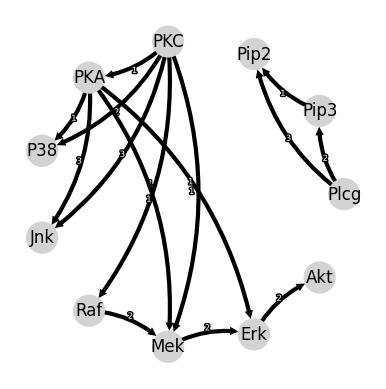

In [7]:
# One-liner plot from result object
result_b.plot(var_names=names_b, node_layout="circular", node_size=0.2, show_colorbar=False, arrow_linewidth=3, link_label_fontsize=6);


---

<a id="3-cedar"></a>
# 3. CEDAR

Scalable causal discovery for autoregressive time series via minimum-lag selection and distance correlation. Requires only **two CI tests per candidate edge** — O(d²) overall.

```python
from causalts.cedar import run_cedar, Cedar
```

<a id="run_cedar"></a>
## `run_cedar`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.cedar.<strong>run_cedar</strong>(<em>df, ci_test, max_lag, *, alpha_cond1=0.05, alpha_cond2=0.05, lag_method='partial_dcor', lag_pvalue_method='t_test', lag_alpha=0.05, n_permutations=200, normalize='minmax', filter_children=True, direction_threshold=1.2, direction_method='dcor', prune=True, alpha_mci=None, sweep_all_lags=False, max_prune_path=4, include_lag0=False, multi_lag=True, multi_lag_keep='first', target_var=None, n_jobs=1, verbose=False, forbidden=None, required=None, impute=None, impute_kwargs=None, include_C=False, c_preset='linear', c_array=None, include_autoreg=True, assume_ar1=True</em>) → <em>CedarResult</em>
</div>

Convenience wrapper around `Cedar(...).run()`. Runs the full CEDAR pipeline and returns a `CedarResult`.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>df</strong> : <em>pd.DataFrame</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Time series data, shape (T, d). Column names are used as variable names.</dd>
<dt><strong>ci_test</strong> : <em>CIT_Base instance</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Any CI test from <code>causalts.ci_tests</code>. Data is set internally before each test.</dd>
<dt><strong>max_lag</strong> : <em>int</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Maximum lag to consider (≥ 1).</dd>
<dt><strong>alpha_cond1</strong> : <em>float, default=0.05</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Significance threshold for Condition 1 (dependence): reject H₀ if p < alpha_cond1.</dd>
<dt><strong>alpha_cond2</strong> : <em>float, default=0.05</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Significance threshold for Condition 2 (independence): accept edge if p ≥ alpha_cond2.</dd>
<dt><strong>lag_method</strong> : <em>str, default='partial_dcor'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Lag importance metric: <code>'partial_dcor'</code> (unbiased dcor on X_j(t) residualised on X_j(t-1) — best lag accuracy for hub graphs), <code>'dcor'</code> (unbiased U-centered distance correlation), or <code>'pearson'</code> (faster, linear only).</dd>
<dt><strong>lag_pvalue_method</strong> : <em>str, default='t_test'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Lag significance test: <code>'t_test'</code> (~200× faster, analytic, best for most data), <code>'circular_shift'</code> (proper for AR data, uses permutations), <code>'permutation'</code> (legacy).</dd>
<dt><strong>lag_alpha</strong> : <em>float, default=0.05</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">P-value threshold for lag significance (used to select candidate lags).</dd>
<dt><strong>n_permutations</strong> : <em>int, default=200</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Permutations for lag significance (only for <code>circular_shift</code>/<code>permutation</code> methods).</dd>
<dt><strong>normalize</strong> : <em>str or None, default='minmax'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Data normalization before lag importance: <code>'minmax'</code>, <code>'zscore'</code>, or <code>None</code>.</dd>
<dt><strong>filter_children</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Skip testing variables where asymmetric dcor strongly suggests they are children, not causes.</dd>
<dt><strong>direction_threshold</strong> : <em>float, default=1.2</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Ratio M[j,i]/M[i,j] above which i is deemed a child of j and filtered. Only applies when <code>filter_children=True</code>.</dd>
<dt><strong>direction_method</strong> : <em>str, default='dcor'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Method for children detection: <code>'dcor'</code> (max lag-importance asymmetry) or <code>'cross_lag'</code> (lag-1 cross-correlation asymmetry — more robust for hub-heavy scale-free graphs).</dd>
<dt><strong>prune</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Apply MCI-style pruning after discovery: test each edge conditioning on parents of both endpoints. Stable (order-independent) removal.</dd>
<dt><strong>alpha_mci</strong> : <em>float or None, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Separate alpha for MCI pruning. When <code>None</code>, uses <code>alpha_cond2</code>. Setting stricter than alpha_cond2 enables permissive discovery + tight pruning (e.g. <code>alpha_cond2=0.00001, alpha_mci=0.01</code> for scale-free graphs).</dd>
<dt><strong>sweep_all_lags</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">When True, test every lag 1..max_lag for each candidate pair regardless of lag-selection significance. CI tests become the sole acceptance gate.</dd>
<dt><strong>max_prune_path</strong> : <em>int, default=4</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Maximum path length for pruning.</dd>
<dt><strong>include_lag0</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Include contemporaneous (lag 0) effects.</dd>
<dt><strong>multi_lag</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Test all significant lags per candidate pair (in importance order) rather than only the top lag.</dd>
<dt><strong>multi_lag_keep</strong> : <em>str, default='first'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'first'</code>: stop at the first accepted lag (fast). <code>'all'</code>: report all accepted lags for maximum recall.</dd>
<dt><strong>target_var</strong> : <em>str or None, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Discover causes of a single target variable only — reduces from O(d²) to O(d) CI tests. Unique to CEDAR.</dd>
<dt><strong>n_jobs</strong> : <em>int, default=1</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Parallelism for lag importance computation.</dd>
<dt><strong>verbose</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Enable debug logging (phase progress, accepted/pruned edges).</dd>
<dt><strong>forbidden</strong> : <em>list of (cause, effect, lag) tuples, optional</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Edges to forbid. Each entry is <code>(cause_var, effect_var, lag)</code> where <code>lag</code> is an int ≥ 1, or <code>None</code> to forbid the pair at all lags. Forbidden edges are skipped before CI tests.</dd>
<dt><strong>required</strong> : <em>list of (cause, effect, lag) tuples, optional</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Edges to force into the final graph regardless of CI test outcome. Same format as <code>forbidden</code>. Required edges bypass children filtering and are protected from MCI pruning.</dd>
<dt><strong>impute</strong> : <em>str or None, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Missing-value strategy. <code>None</code> / <code>'pairwise_complete'</code> — drop NaN rows per CI test (default). <code>'var_em'</code> — fill NaN via iterative VAR-EM before discovery.</dd>
<dt><strong>impute_kwargs</strong> : <em>dict, optional</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Extra keyword arguments forwarded to the imputer (e.g. <code>{"p": 2, "n_iter": 10}</code> for VAR-EM).</dd>
<dt><strong>include_C</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Append a nonstationarity time-index variable (C node) to the data before discovery. C is treated as a pure cause (never as an effect). Forces <code>include_lag0=True</code> so the contemporaneous C(t) → X_j(t) edge can be discovered.</dd>
<dt><strong>c_preset</strong> : <em>str, default='linear'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Basis function for the C node: <code>'linear'</code>, <code>'quadratic'</code>, <code>'sigmoid'</code>, <code>'sin'</code>, <code>'step'</code>, or <code>'multi'</code> (multiple basis columns). Only used when <code>include_C=True</code> and <code>c_array=None</code>.</dd>
<dt><strong>c_array</strong> : <em>np.ndarray or None, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Custom C node array, shape (T,) or (T, k). Overrides <code>c_preset</code> when provided.</dd>
<dt><strong>include_autoreg</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Detect and include autoregressive self-loop edges based on AR order estimation. Exposes <code>CedarResult.ar_order</code> and <code>CedarResult.ar_violations</code>.</dd>
<dt><strong>assume_ar1</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">When True, assume AR(1) without running sequential conditional CI tests (faster). When False, estimate AR order via sequential tests up to max_lag.</dd>
</dl>

**Returns:** `CedarResult`

</div>

---

<a id="cedar-class"></a>
## `Cedar`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
<em>class</em> causalts.cedar.<strong>Cedar</strong>(<em>df, ci_test, max_lag, **kwargs</em>)
</div>

Object-oriented interface. Accepts the same parameters as `run_cedar`. Call `.run()` to execute.

**Key method:** `algo.run()` → `CedarResult`

---

<a id="cedarresult"></a>
## `CedarResult`

Result object returned by `run_cedar` / `Cedar.run()`. Inherits from `CausalResult` and provides plotting and DoWhy bridge methods.

**Attributes:**

| Attribute | Shape | Description |
|-----------|-------|-------------|
| `cg_tig` | `(d, d, max_lag+1)` | Binary adjacency. `cg_tig[cause, effect, lag] == 1` means cause(t-lag) → effect(t) |
| `val_matrix` | `(d, d, max_lag+1)` | CI test statistic (strength) per edge |
| `pvalue_matrix` | `(d, d, max_lag+1)` | P-value from Cond1 for each candidate edge |
| `lag_importance` | `(d, d, max_lag+1)` | Distance correlation scores used for lag selection |
| `lag_pvalues` | `(d, d, max_lag+1)` | P-values for lag significance |
| `selected_lags` | `(d, d)` | Selected lag per pair (NaN if none) |
| `var_names` | `list[str]` | Variable names |
| `n_tests` | `int` | Total CI tests performed |
| `pruned` | `bool` | Whether MCI pruning was applied |
| `ar_order` | `dict` | Detected AR order per variable (col name → int). Empty if `include_autoreg=False` |
| `ar_violations` | `dict` | Variables with AR order ≥ 2 (var → order). Useful for diagnostics |
| `c_node_names` | `list[str]` | Names of appended C-node columns (empty if `include_C=False`) |

**Methods:**
- `result.plot(**kwargs)` — calls `tp.plot_graph` with `val_matrix` for edge coloring
- `result.estimate_effect(treatment, outcome, ...)` — DoWhy ATE via backdoor
- `result.fit_scm(mechanism_type='auto')` — fit DoWhy GCM (AR(1) self-lags restored)
- `result.counterfactual(intervention, target)` — what-if analysis
- `result.attribute_anomaly(anomaly, target)` — Shapley root cause attribution

CedarResult(vars=11, max_lag=3, edges=27, lag_method='partial_dcor', lag_pvalue_method='t_test', alpha_cond1=0.01, alpha_cond2=0.01, pruned=True, n_tests=71)
Edges: 27
CI tests: 71
F1=0.945  Precision=0.963  TPR=0.929  SHD=3


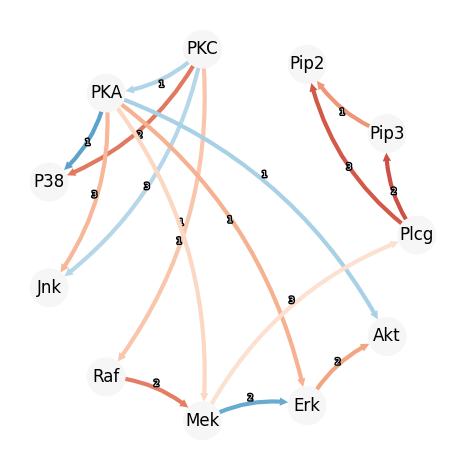


target_var='Mek': 13 edges, 8 CI tests

With BK: CedarResult(vars=11, max_lag=3, edges=27, lag_method='partial_dcor', lag_pvalue_method='t_test', alpha_cond1=0.01, alpha_cond2=0.01, pruned=True, n_tests=72, forbidden=1, required=1)

Pairwise-complete: 77 tests, 25 edges
VAR-EM imputed:    77 tests, 28 edges


In [8]:
from causalts.synthetic_data.synthetic_datasets import ex3

result_ex3 = ex3(seed=42, T=300)
df_ex3 = result_ex3["df"]
true_graph_ex3 = result_ex3["ground_truth"]

ci_b = PartialCorr(data=df_b.values)

# --- Functional API ---
cedar_result = run_cedar(
    df=df_b,
    ci_test=ci_b,
    max_lag=maxlag_b,
    alpha_cond1=0.01,
    alpha_cond2=0.01,
    lag_method="partial_dcor",
    normalize="minmax",
    prune=True,
    multi_lag=False,
    multi_lag_keep="first",
    verbose=False,
)
print(cedar_result)
print(f"Edges: {int((cedar_result.cg_tig == 1).sum())}")
print(f"CI tests: {cedar_result.n_tests}")

# Evaluate
m = evaluate_graph(cedar_result.cg_tig, true_b)
print(f"F1={m['F1']:.3f}  Precision={m['Precision']:.3f}  TPR={m['TPR']:.3f}  SHD={m['SHD']}")

# Plot
cedar_result.plot(var_names=names_b, node_layout="circular", node_size=0.2,
                 show_colorbar=False, arrow_linewidth=3, link_label_fontsize=6)
plt.tight_layout()
plt.show()

# --- target_var mode: O(d) tests instead of O(d^2) ---
cedar_target = run_cedar(
    df=df_b,
    ci_test=PartialCorr(data=df_b.values),
    max_lag=maxlag_b,
    target_var="Mek",
    verbose=False,
)
print(f"\ntarget_var='Mek': {int((cedar_target.cg_tig == 1).sum())} edges, {cedar_target.n_tests} CI tests")

# --- Background knowledge ---
cedar_bk = run_cedar(
    df=df_b,
    ci_test=PartialCorr(data=df_b.values),
    max_lag=maxlag_b,
    forbidden=[("Plcg", "Pip2", None)],  # forbid Plcg->Pip2 at any lag
    required=[("PKC",  "Raf",  1)],       # force PKC(t-1)->Raf into graph
    verbose=False,
)
print(f"\nWith BK: {cedar_bk}")

# --- Missing values: pairwise-complete (default) vs VAR-EM ---
arr_miss = df_b.to_numpy(dtype=float).copy()
arr_miss[np.random.default_rng(42).random(arr_miss.shape) < 0.15] = np.nan
df_b_miss = pd.DataFrame(arr_miss, columns=df_b.columns)

cedar_pw    = run_cedar(df_b_miss, PartialCorr(data=np.zeros((2,2))), max_lag=maxlag_b)
cedar_varem = run_cedar(df_b_miss, PartialCorr(data=np.zeros((2,2))), max_lag=maxlag_b,
                      impute="var_em")
print(f"\nPairwise-complete: {cedar_pw.n_tests} tests, {int(cedar_pw.cg_tig.sum())} edges")
print(f"VAR-EM imputed:    {cedar_varem.n_tests} tests, {int(cedar_varem.cg_tig.sum())} edges")

---

<a id="4-grace"></a>
# 4. GRACE

Two-stage framework: CDNOTS skeleton + neural gated refinement with L0 regularization.

```python
from causalts.grace import run_cdnots_gated
from causalts.utils import evaluate_graph
```

<a id="run_cdnots_gated"></a>
## `run_cdnots_gated`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.grace.<strong>run_cdnots_gated</strong>(<em>df, max_lag, alpha=0.05, ci_test_class=None, skeleton=None, skeleton_runtime=0.0, gate_threshold=0.5, normalize=True, max_epochs=150, batch_size=None, patience=20, device=None, verbose=True, ground_truth=None, model_seed=None, include_C_in_model=False, lambda_cv=False, impute=None, impute_kwargs=None, discrete_cols=None, **model_kwargs</em>) → <em>GraceResult</em>
</div>

Run CDNOTS skeleton discovery followed by single gated neural refinement.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>df</strong> : <em>DataFrame</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Time series data (T, d).</dd>
<dt><strong>max_lag</strong> : <em>int</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Maximum lag.</dd>
<dt><strong>alpha</strong> : <em>float, default=0.05</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Significance level for CDNOTS skeleton.</dd>
<dt><strong>ci_test_class</strong> : <em>class, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">CI test class (default: auto-select ParCorr).</dd>
<dt><strong>skeleton</strong> : <em>ndarray, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Pre-computed binary skeleton array (d, d, max_lag+1). Skips CDNOTS phase if provided.</dd>
<dt><strong>skeleton_runtime</strong> : <em>float, default=0.0</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Wall-clock time of the pre-computed skeleton (for reporting).</dd>
<dt><strong>gate_threshold</strong> : <em>float, default=0.5</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Threshold for gate values.</dd>
<dt><strong>normalize</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Z-score normalize data before training.</dd>
<dt><strong>max_epochs</strong> : <em>int, default=150</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Maximum training epochs.</dd>
<dt><strong>batch_size</strong> : <em>int, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Batch size (<code>None</code> = auto).</dd>
<dt><strong>patience</strong> : <em>int, default=20</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Early stopping patience.</dd>
<dt><strong>device</strong> : <em>str, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'cuda'</code>, <code>'mps'</code>, <code>'cpu'</code>, or <code>None</code> (auto-detect).</dd>
<dt><strong>verbose</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Print progress.</dd>
<dt><strong>ground_truth</strong> : <em>ndarray, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">If given, logs evaluation metrics.</dd>
<dt><strong>model_seed</strong> : <em>int, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Random seed for reproducibility.</dd>
<dt><strong>include_C_in_model</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Include the time-index node C as input to the neural model. C-related edges are stripped from the output graph.</dd>
<dt><strong>lambda_cv</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Use cross-validation for lambda selection instead of the adaptive formula.</dd>
<dt><strong>impute</strong> : <em>str or None, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Missing-value strategy. <code>None</code> — no imputation. <code>'var_em'</code> — iterative VAR-EM.</dd>
<dt><strong>impute_kwargs</strong> : <em>dict or None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Extra keyword arguments forwarded to the imputer.</dd>
<dt><strong>discrete_cols</strong> : <em>list or None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Column names or indices of discrete variables.</dd>
<dt><strong>**model_kwargs</strong> : <em>dict</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Forwarded to GatedCausalDiscovery (e.g. <code>hidden_dim</code>, <code>lr</code>).</dd>
</dl>

**Returns:** `GraceResult` — Result object with attributes `cg_tig` (binary graph), `gate_values` (continuous gate values), `skeleton`, `lambda_l0`, `gate_threshold`, `runtime`, and inherited plotting / DoWhy bridge methods.

</div>

In [9]:
# GRACE on a 25-var synthetic graph
gen = SCPGraphGenerator(n_vars=25, max_lag=5)
result = gen.sample(seed=42, T=2000)

res = run_cdnots_gated(
    df=result["df"], max_lag=result["max_lag"],
    verbose=True, device="cpu", model_seed=42,
)
G_hat, gate_vals = res.cg_tig, res.gate_values

ParCorrGPU requires CUDA; falling back to CPU PartialCorr


Step 1: CDNOTS skeleton discovery...


Depth=7, working on node 25: 100%|██████████| 26/26 [00:00<00:00, 3209.11it/s]
Seed set to 42


  Skeleton: 66 edges, density=0.018 (13.7s)

Step 2: Single gated training with skeleton mask...
  lambda_L0=0.0261 (formula)
  Training done: 56 gates > 0.5 (28.7s)

Result: 56 edges at threshold=0.5 (42.4s total)
  Skeleton: 13.7s, Training: 28.7s


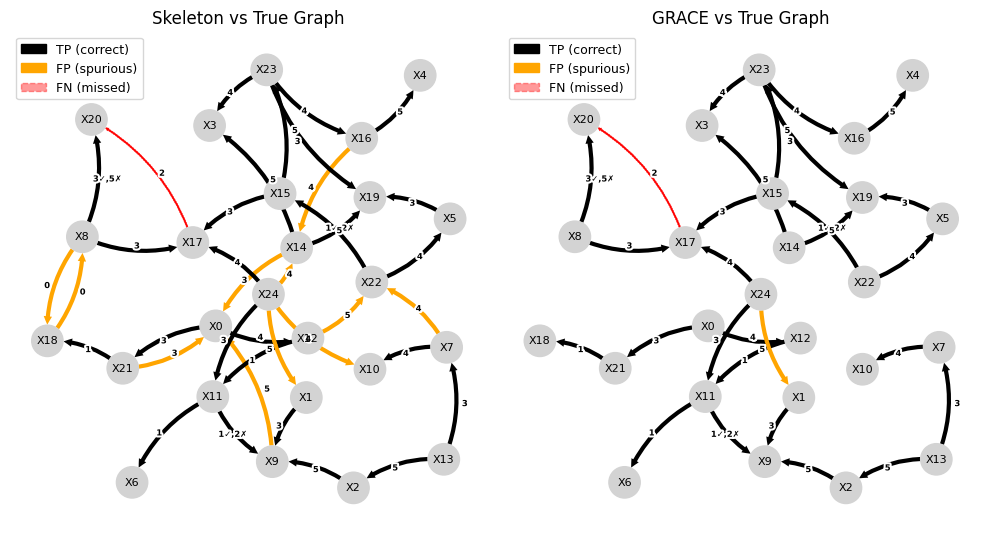

Metric         Skeleton      GRACE
Precision         0.773      0.911
TPR               0.981      0.981
F1                0.864      0.944
SHD              16.000      6.000


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
_,_,pos = tp.compare_graphs(
    graph_true=result["ground_truth"], graph_discovered=res.skeleton,
    var_names=result["var_names"], node_layout="neato",
    node_size=0.15, arrow_linewidth=3, link_label_fontsize=6,
    title="Skeleton vs True Graph",
    legend_loc=None,
    tp_color='black',
    fig_ax=(fig, axes[0]),
    return_pos=True, node_label_size=8,
)
tp.compare_graphs(
    graph_true=result["ground_truth"], graph_discovered=G_hat,
    var_names=result["var_names"],
    node_size=0.15, arrow_linewidth=3, link_label_fontsize=6,
    title="GRACE vs True Graph",
    legend_loc=None,
    tp_color='black',
    fig_ax=(fig, axes[1]),
    node_pos=pos,
    node_label_size=8,
)

plt.tight_layout()
plt.show()

skel_metrics = evaluate_graph(res.skeleton, result["ground_truth"])
grace_metrics = evaluate_graph(G_hat, result["ground_truth"])

print(f"{'Metric':<12} {'Skeleton':>10} {'GRACE':>10}")
for k in ["Precision", "TPR", "F1", "SHD"]:
    print(f"{k:<12} {skel_metrics[k]:>10.3f} {grace_metrics[k]:>10.3f}")

---

<a id="5-lucid"></a>
# 5. LUCID

Causal discovery assumes **causal sufficiency** — that every common cause is measured.
When it fails, an unobserved common cause of two variables shows up as an edge between
them. LUCID is not a discovery algorithm: it *corrects* an already-discovered graph.

It first infers, from the spectrum of the VAR-residual correlation matrix, whether the
latent confounding is **sparse** (a cause touching a few variables) or **pervasive** (a
factor loading on everything), then applies the correction matched to that regime — the
two regimes need opposite treatments, and applying the wrong one is damaging.

```python
from causalts.confounders import run_lucid, tetrad_filter, pds_filter
```

<a id="run_lucid"></a>
## `run_lucid`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.confounders.<strong>run_lucid</strong>(<em>df_obs, max_lag, ci=None, discovery=None, **kwargs</em>) &rarr; <em>LucidResult</em>
</div>

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>df_obs</strong> : <em>DataFrame</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Observed time series (T, d).</dd>
<dt><strong>max_lag</strong> : <em>int</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Maximum lag.</dd>
<dt><strong>ci</strong> : <em>CIT_Base, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">CI test for the base skeleton search (default: <code>ParCorrGPU</code>).</dd>
<dt><strong>discovery</strong> : <em>CausalResult, ndarray or callable, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Reuse an existing discovery instead of re-running the skeleton search. Exact, because both regimes run the <em>same</em> base engine — routing changes only the correction applied afterwards.</dd>
</dl>

**Returns:** `LucidResult` — `cg_tig` (corrected graph), `regime`, `spectral_ratio`, `tau`, `n_factors`, `factor_loadings`, plus inherited plotting / DoWhy methods.

</div>

> **On `factor_loadings`:** descriptive summaries of the estimated factor subspace. They
> are rotation-ambiguous and are **not** identified latent variables — do not read a
> loading as "this factor is inflation".

Every result object also exposes the correction directly, so it composes with any engine:

| Method | Strategy |
|---|---|
| `res.deconfound()` | Regime-adaptive (LUCID) — **the recommended path** |
| `res.tetrad_filter()` | Fixed comparator: always assumes pervasive factor structure |
| `res.pds_filter()` | Fixed comparator: post-double-selection against observed controls |


In [14]:
# A panel where causal sufficiency FAILS: one latent factor loads on all 8 variables,
# on top of 3 genuine lag-1 edges. The factor is never put in the DataFrame.
rng_l = np.random.default_rng(0)
T_l, d_l, edge_l = 1500, 8, 0.7
latent = rng_l.standard_normal((T_l, 1)) @ (rng_l.uniform(0.6, 1.0, (1, d_l)))
X_l = np.zeros((T_l, d_l))
noise_l = rng_l.standard_normal((T_l, d_l))
true_edges_l = [(0, 1, 1), (2, 3, 1), (4, 5, 1)]
for t in range(1, T_l):
    X_l[t] = noise_l[t] + latent[t]              # <- the unobserved common cause
    for (i, j, lag) in true_edges_l:
        X_l[t, j] += edge_l * X_l[t - lag, i]

df_l = pd.DataFrame(X_l, columns=[f"X{i}" for i in range(d_l)])
names_l = df_l.columns.tolist()
true_l = np.zeros((d_l, d_l, 2), dtype=np.int8)
for (i, j, lag) in true_edges_l:
    true_l[i, j, lag] = 1

# 1) Plain discovery — the latent factor shows up as spurious contemporaneous edges.
cd_l = run_cdnots(df_l, ParCorrGPU(df_l.values.copy()), num_lags=1,
                  include_C=False, alpha=0.01, verbose=False)
g_plain = np.asarray(cd_l.cg_tig)[:d_l, :d_l, :2]

# 2) Correct it. .deconfound() reuses the skeleton above — no re-discovery.
lucid_l = cd_l.deconfound()
g_lucid = np.asarray(lucid_l.cg_tig)

print(f"regime        : {lucid_l.regime}   (factors detected: {lucid_l.n_factors})")
print(f"router        : R = {lucid_l.spectral_ratio:.3f}  vs  tau = {lucid_l.tau:.3f}")
print(f"lag-0 edges   : {int(g_plain[:, :, 0].sum()):3d} -> {int(g_lucid[:, :, 0].sum()):3d}"
      f"   (ground truth has 0)")
print(f"lag-1 edges   : {int(g_plain[:, :, 1].sum()):3d} -> {int(g_lucid[:, :, 1].sum()):3d}"
      f"   (ground truth has {len(true_edges_l)})")
print(f"top loadings  : {[(v, round(w, 2)) for v, w in lucid_l.top_factor_variables(0, 3)]}")


regime        : pervasive   (factors detected: 1)
router        : R = 0.538  vs  tau = 0.374
lag-0 edges   :  23 ->   0   (ground truth has 0)
lag-1 edges   :   4 ->   4   (ground truth has 3)
top loadings  : [('X6', -0.42), ('X1', -0.4), ('X3', -0.36)]


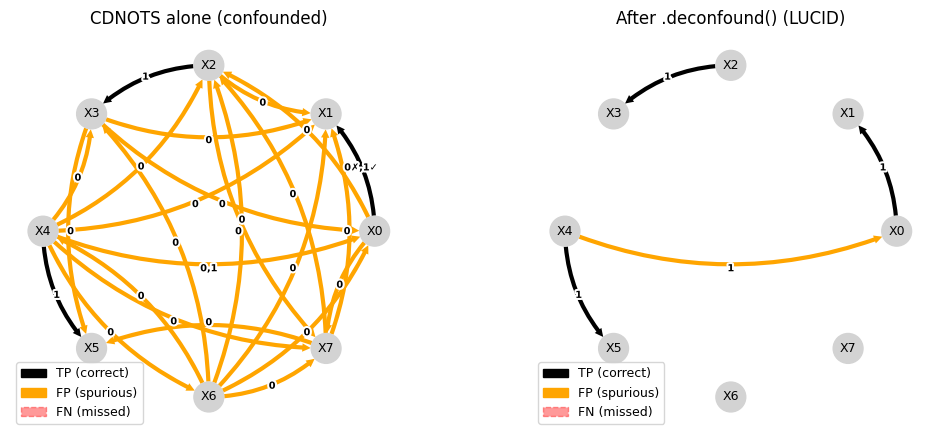

Metric           CDNOTS     +LUCID
Precision         0.111      0.750
TPR               1.000      1.000
F1                0.200      0.857
SHD              24.000      1.000


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
_, _, pos_l = tp.compare_graphs(
    graph_true=true_l, graph_discovered=g_plain, var_names=names_l,
    node_layout="circular", node_size=0.18, arrow_linewidth=3,
    link_label_fontsize=7, title="CDNOTS alone (confounded)",
    legend_loc="lower left", tp_color="black", fig_ax=(fig, axes[0]),
    return_pos=True, node_label_size=9,
)
tp.compare_graphs(
    graph_true=true_l, graph_discovered=g_lucid, var_names=names_l,
    node_size=0.18, arrow_linewidth=3, link_label_fontsize=7,
    title="After .deconfound() (LUCID)", legend_loc="lower left",
    tp_color="black", fig_ax=(fig, axes[1]), node_pos=pos_l, node_label_size=9,
)
plt.tight_layout()
plt.show()

m_plain = evaluate_graph(g_plain, true_l)
m_lucid = evaluate_graph(g_lucid, true_l)
print(f"{'Metric':<12} {'CDNOTS':>10} {'+LUCID':>10}")
for k in ["Precision", "TPR", "F1", "SHD"]:
    print(f"{k:<12} {m_plain[k]:>10.3f} {m_lucid[k]:>10.3f}")

# Recall is unchanged: the correction removed false positives without dropping a
# true edge. It rewrites the lag-0 slice, so the surviving lag-1 false positive
# is out of its reach -- deconfounding is not a general-purpose graph cleaner.


---

<a id="6-plotting"></a>
# 6. Plotting

```python
import causalts.plotting as tp
```

<a id="plot_graph"></a>
## `plot_graph`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.plotting.<strong>plot_graph</strong>(<em>graph, var_names=None, node_layout='circular', node_pos=None, node_size=0.3, arrow_linewidth=8.0, link_label_fontsize=10, curved_radius=0.2, fig_ax=None, figsize=None, show_colorbar=True, return_pos=False, val_matrix=None, title=None</em>)
</div>

Draw a causal graph as a network. Nodes are variables, curved arrows are lagged dependencies, straight arrows are contemporaneous.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>graph</strong> : <em>ndarray (N, N, tau+1)</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Causal graph.</dd>
<dt><strong>var_names</strong> : <em>list[str], default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Variable names.</dd>
<dt><strong>node_layout</strong> : <em>str, default='circular'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'circular'</code>, <code>'spring'</code>, <code>'kamada_kawai'</code>, <code>'shell'</code>, <code>'spectral'</code>, <code>'neato'</code>, <code>'fdp'</code>, <code>'sfdp'</code>, <code>'dot'</code>, <code>'twopi'</code>, <code>'circo'</code>.</dd>
<dt><strong>node_pos</strong> : <em>dict, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Pre-computed positions (overrides layout).</dd>
<dt><strong>node_size</strong> : <em>float, default=0.3</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Node radius.</dd>
<dt><strong>arrow_linewidth</strong> : <em>float, default=8.0</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Edge line width.</dd>
<dt><strong>link_label_fontsize</strong> : <em>int, default=10</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Lag label font size.</dd>
<dt><strong>curved_radius</strong> : <em>float, default=0.2</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Curvature for lagged edges.</dd>
<dt><strong>fig_ax</strong> : <em>tuple, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>(fig, ax)</code> for embedding in subplots.</dd>
<dt><strong>show_colorbar</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Show edge/node colorbars.</dd>
<dt><strong>return_pos</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Return <code>(fig, ax, pos)</code> instead of <code>(fig, ax)</code>.</dd>
<dt><strong>val_matrix</strong> : <em>ndarray, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Edge values for coloring.</dd>
</dl>
</div>

> **Note:** Graphviz layouts (`neato`, `fdp`, `sfdp`, `dot`, `twopi`, `circo`) require `graphviz` to be installed. If unavailable, they fall back to `circular`.

**Returns:** `(fig, ax)` or `(fig, ax, pos)` when `return_pos=True`

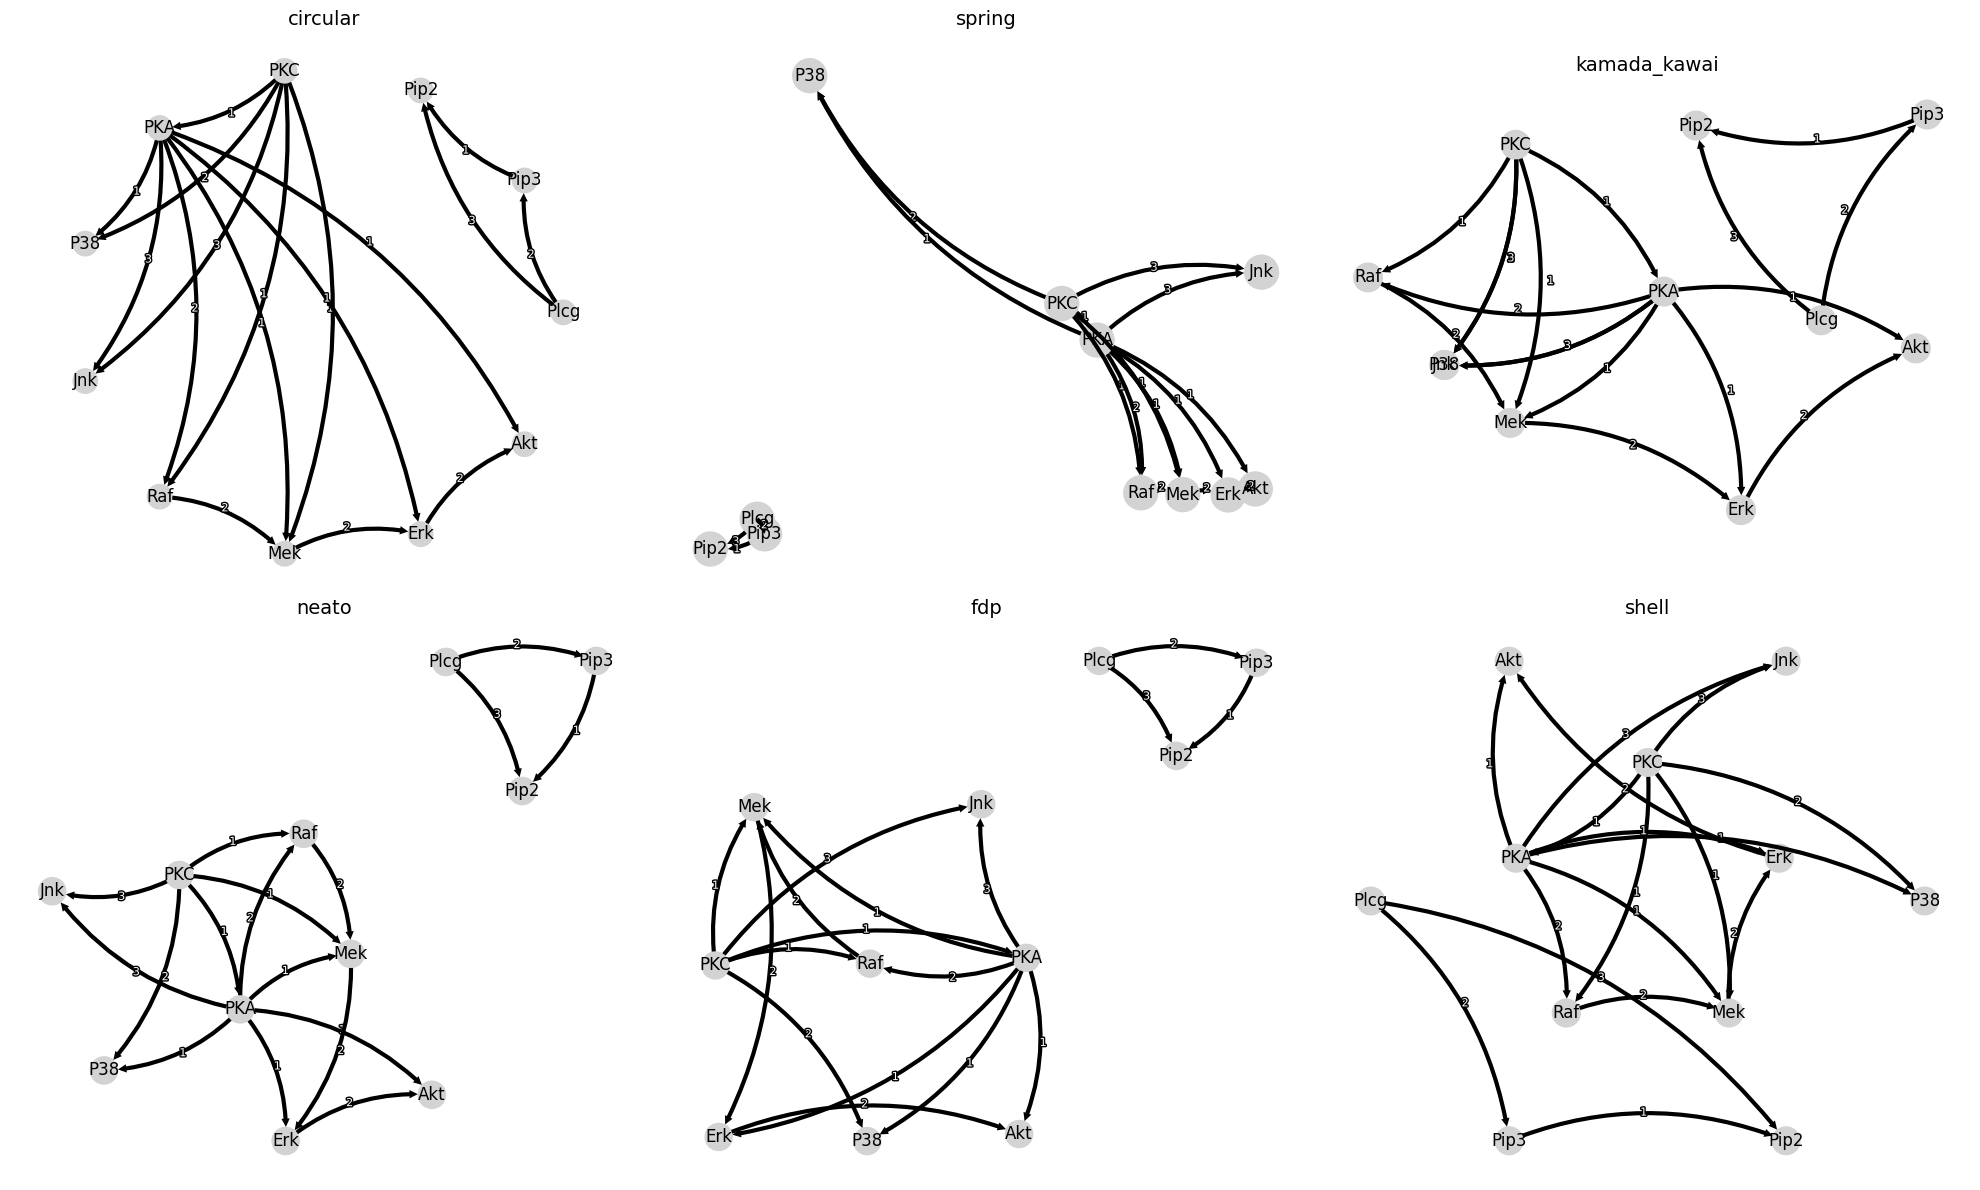

In [16]:
# Layout comparison (2x3 grid)
layouts = ["circular", "spring", "kamada_kawai", "neato", "fdp", "shell"]
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for ax, layout in zip(axes.flat, layouts):
    tp.plot_graph(
        graph=true_b, var_names=names_b,
        node_layout=layout, node_size=0.1, arrow_linewidth=3,
        link_label_fontsize=8, show_colorbar=False,
        fig_ax=(fig, ax),
    )
    ax.set_title(layout, fontsize=14)
plt.tight_layout()
plt.show()

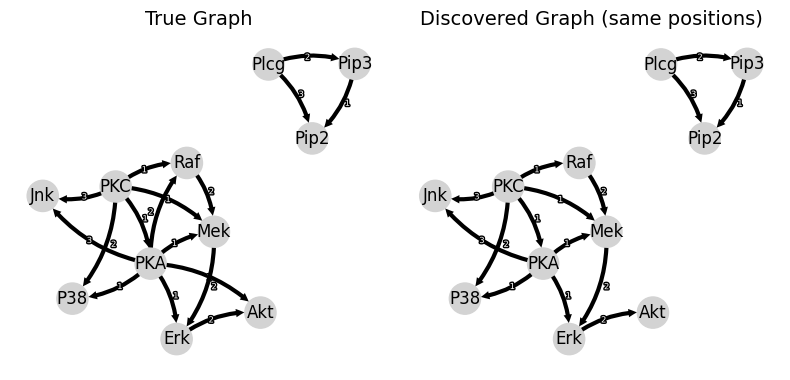

In [19]:
# Shared positions: use return_pos to capture layout, then reuse with node_pos
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

_, _, pos = tp.plot_graph(
    graph=true_b, var_names=names_b,
    node_layout="neato", node_size=0.2, arrow_linewidth=3,
    link_label_fontsize=6, show_colorbar=False,
    fig_ax=(fig, axes[0]), return_pos=True,
)
axes[0].set_title("True Graph", fontsize=14)

tp.plot_graph(
    graph=graph_b, var_names=names_b,
    node_pos=pos, node_size=0.2, arrow_linewidth=3,
    link_label_fontsize=6, show_colorbar=False,
    fig_ax=(fig, axes[1]),
)
axes[1].set_title("Discovered Graph (same positions)", fontsize=14)
plt.tight_layout()
plt.show()

<a id="plot_time_series_graph"></a>
## `plot_time_series_graph`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.plotting.<strong>plot_time_series_graph</strong>(<em>graph, var_names=None, arrow_linewidth=4, node_size=0.1, figsize=None, order='auto'</em>)
</div>

Time-unrolled visualization showing each variable at each lag as a separate node. By default, variables are reordered to minimize edge crossings using the barycenter heuristic.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>graph</strong> : <em>ndarray (N, N, tau+1)</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Causal graph.</dd>
<dt><strong>var_names</strong> : <em>list[str], default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Variable names.</dd>
<dt><strong>arrow_linewidth</strong> : <em>float, default=4</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Edge width.</dd>
<dt><strong>node_size</strong> : <em>float, default=0.1</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Node size.</dd>
<dt><strong>figsize</strong> : <em>tuple, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Figure size.</dd>
<dt><strong>order</strong> : <em>list[int] or str, default='auto'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'auto'</code> uses barycenter heuristic to minimize edge crossings. Pass a list of variable indices for manual ordering (top to bottom).</dd>
</dl>
</div>

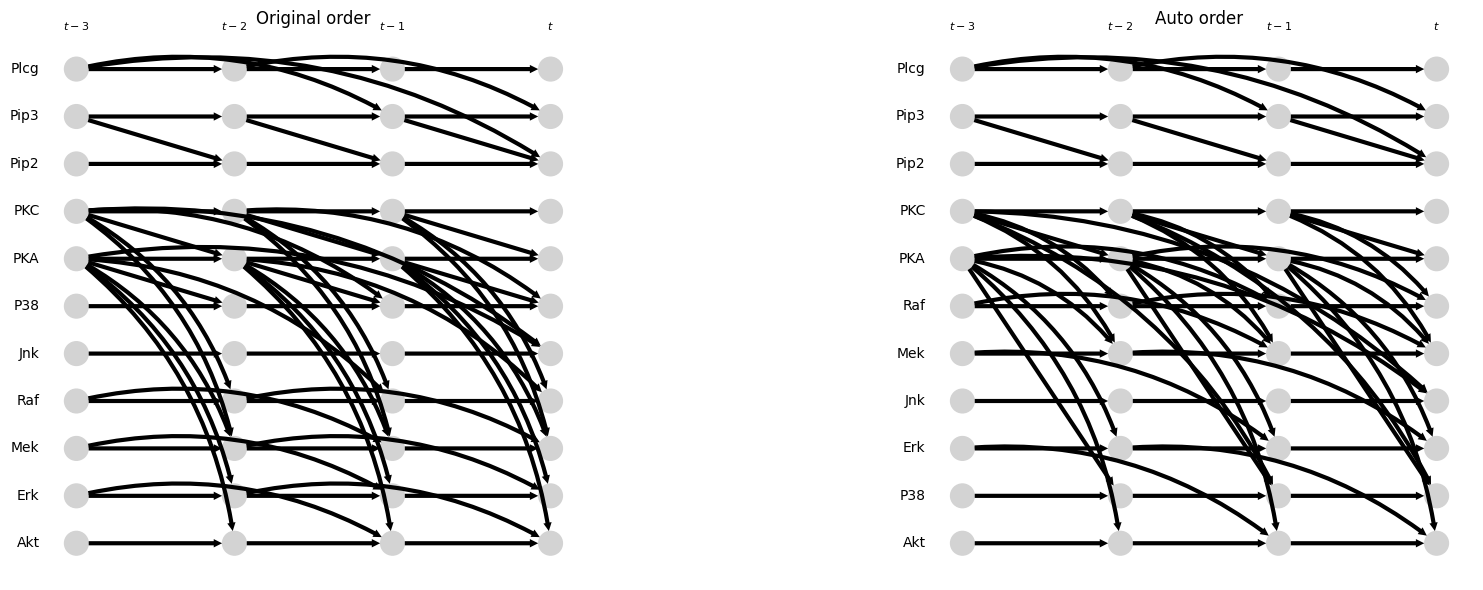

In [20]:
# Compare default order vs auto (barycenter) ordering
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

tp.plot_time_series_graph(
    true_b, var_names=names_b,
    arrow_linewidth=3, node_size=0.05,
    order=list(range(len(names_b))),  # original order
    fig_ax=(fig, axes[0]),
)
axes[0].set_title("Original order", fontsize=12)

tp.plot_time_series_graph(
    true_b, var_names=names_b,
    arrow_linewidth=3, node_size=0.05,
    order="auto",  # barycenter heuristic (default)
    fig_ax=(fig, axes[1]),
)
axes[1].set_title("Auto order", fontsize=12)

plt.tight_layout()
plt.show()

<a id="compare_graphs"></a>
## `compare_graphs`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.plotting.<strong>compare_graphs</strong>(<em>graph_true, graph_discovered, var_names=None, node_layout='circular', node_pos=None, node_size=0.3, arrow_linewidth=8.0, link_label_fontsize=10, tp_color='green', fp_color='orange', fn_color='red', fn_style='dashed', fn_linewidth=None, show_legend=True, legend_loc='lower left', fig_ax=None, figsize=None, return_pos=False, title=None</em>)
</div>

Overlay true and discovered graphs with TP/FP/FN color coding.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>graph_true</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Ground truth (N, N, tau+1).</dd>
<dt><strong>graph_discovered</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Discovered graph.</dd>
<dt><strong>var_names</strong> : <em>list[str], default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Variable names.</dd>
<dt><strong>node_layout</strong> : <em>str, default='circular'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Layout algorithm.</dd>
<dt><strong>node_pos</strong> : <em>dict, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Pre-computed positions.</dd>
<dt><strong>tp_color</strong> : <em>str, default='green'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">True positive color.</dd>
<dt><strong>fp_color</strong> : <em>str, default='orange'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">False positive color.</dd>
<dt><strong>fn_color</strong> : <em>str, default='red'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">False negative color.</dd>
<dt><strong>fn_style</strong> : <em>str, default='dashed'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">FN line style.</dd>
<dt><strong>fn_linewidth</strong> : <em>float, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">FN line width (default: 40% of <code>arrow_linewidth</code>).</dd>
<dt><strong>show_legend</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Show TP/FP/FN legend.</dd>
<dt><strong>legend_loc</strong> : <em>str, default='lower left'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Legend location.</dd>
<dt><strong>return_pos</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Return positions.</dd>
</dl>
</div>

**Returns:** `(fig, ax)` or `(fig, ax, pos)` when `return_pos=True`

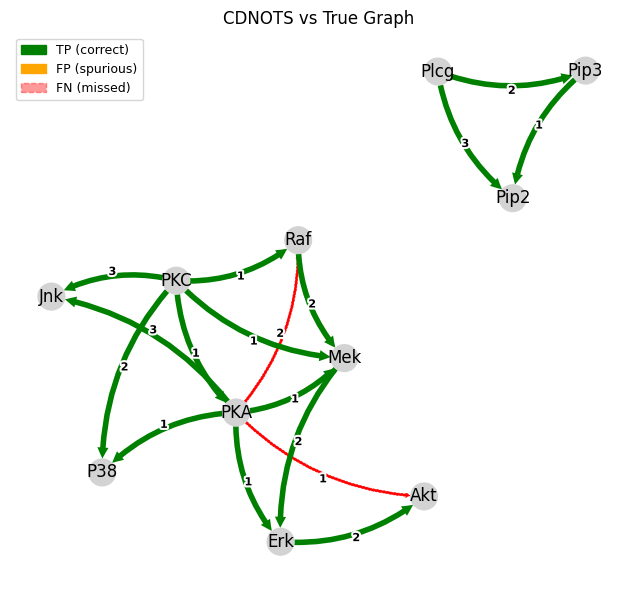

In [21]:
fig, ax = tp.compare_graphs(
    graph_true=true_b, graph_discovered=graph_b,
    var_names=names_b, node_layout="neato",
    node_size=0.1, arrow_linewidth=4, link_label_fontsize=8,
    figsize=(8, 6), title="CDNOTS vs True Graph",
    legend_loc="upper left",
    node_pos=pos
)
plt.tight_layout()
plt.show()

<a id="plot_metrics_summary"></a>
## `plot_metrics_summary`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.plotting.<strong>plot_metrics_summary</strong>(<em>graph_true, graph_discovered, metrics=None, level='lag', exclude_self_loops=False, fig_ax=None, figsize=None, bar_color='steelblue', title=None</em>)
</div>

Horizontal bar chart of evaluation metrics.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>graph_true</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Ground truth.</dd>
<dt><strong>graph_discovered</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Discovered graph.</dd>
<dt><strong>metrics</strong> : <em>list[str], default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Metrics to show (default: Precision, Recall, F1, SHD).</dd>
<dt><strong>level</strong> : <em>str, default='lag'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'lag'</code> (per-lag) or <code>'pair'</code> (pair-level).</dd>
<dt><strong>exclude_self_loops</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Exclude autodependencies from per-lag metrics.</dd>
<dt><strong>fig_ax</strong> : <em>tuple, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>(fig, ax)</code> for subplots.</dd>
<dt><strong>bar_color</strong> : <em>str, default='steelblue'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Bar color.</dd>
</dl>
</div>

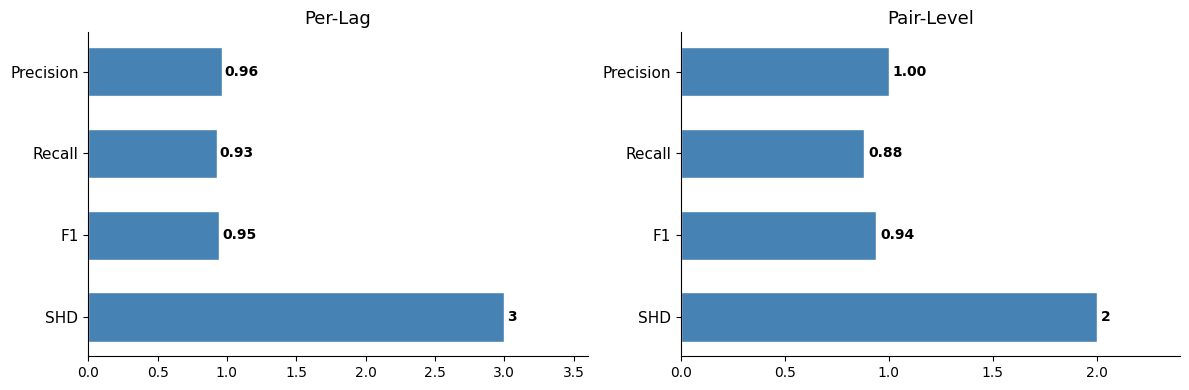

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tp.plot_metrics_summary(true_b, graph_b, title="Per-Lag", fig_ax=(fig, axes[0]))
tp.plot_metrics_summary(true_b, graph_b, level="pair", title="Pair-Level", fig_ax=(fig, axes[1]))
plt.tight_layout()
plt.show()

> **Tip:** Per-lag metrics can be inflated by autodependencies (easy to discover). Use
> `exclude_self_loops=True` to make per-lag directly comparable with pair-level.

<a id="plot_lag_metrics"></a>
## `plot_lag_metrics`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.plotting.<strong>plot_lag_metrics</strong>(<em>graph_true, graph_discovered, metrics=None, cmap='YlGn', annotate=True, figsize=None, title=None</em>)
</div>

Heatmap of precision/recall/F1 broken down by lag.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>graph_true</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Ground truth.</dd>
<dt><strong>graph_discovered</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Discovered graph.</dd>
<dt><strong>metrics</strong> : <em>list[str], default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Default: Precision, Recall, F1.</dd>
<dt><strong>cmap</strong> : <em>str, default='YlGn'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Colormap.</dd>
<dt><strong>annotate</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Show values in cells.</dd>
</dl>
</div>

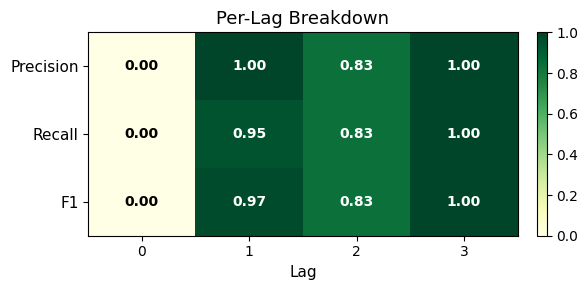

In [23]:
tp.plot_lag_metrics(true_b, graph_b, title="Per-Lag Breakdown", figsize=(6, 3))
plt.tight_layout()
plt.show()

<a id="plot_pvalue_distribution"></a>
## `plot_pvalue_distribution`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.plotting.<strong>plot_pvalue_distribution</strong>(<em>pvalue_matrix, graph_true, graph_discovered=None, bins=30, fig_ax=None, figsize=None, alpha_line=None, true_edge_color='green', non_edge_color='grey', log_scale=False, title=None</em>)
</div>

Histogram of p-values split by edge classification.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>pvalue_matrix</strong> : <em>ndarray or CausalGraph</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">P-value matrix (N, N, tau+1) or <code>cg_obj</code> with <code>.pvalue_matrix</code>.</dd>
<dt><strong>graph_true</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Ground truth.</dd>
<dt><strong>graph_discovered</strong> : <em>ndarray, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">If given, restrict to discovered edges (TP vs FP).</dd>
<dt><strong>bins</strong> : <em>int, default=30</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Number of histogram bins.</dd>
<dt><strong>alpha_line</strong> : <em>float, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Vertical line at significance level.</dd>
<dt><strong>log_scale</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Log10 x-axis.</dd>
<dt><strong>true_edge_color</strong> : <em>str, default='green'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Color for true edges / TP.</dd>
<dt><strong>non_edge_color</strong> : <em>str, default='grey'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Color for non-edges / FP.</dd>
</dl>
</div>

**Two modes:**
- **Without** `graph_discovered`: all tested pairs, split into "True edges" vs "Non-edges"
- **With** `graph_discovered`: only discovered edges, split into "TP" vs "FP"

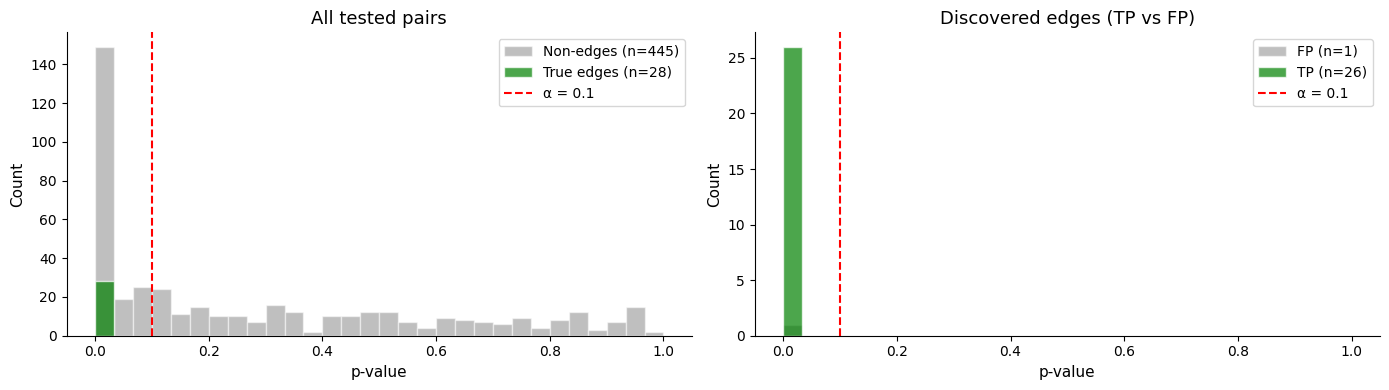

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# All tested pairs
tp.plot_pvalue_distribution(
    result_b, true_b, alpha_line=0.1,
    title="All tested pairs", fig_ax=(fig, axes[0]),
)

# Only discovered edges (TP vs FP)
tp.plot_pvalue_distribution(
    result_b, true_b, graph_discovered=graph_b,
    alpha_line=0.1, title="Discovered edges (TP vs FP)",
    fig_ax=(fig, axes[1]),
)
plt.tight_layout()
plt.show()


<a id="build_pvalue_matrix"></a>
## `build_pvalue_matrix`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.cdnots.<strong>build_pvalue_matrix</strong>(<em>pvals, num_vars, max_lag, aggregation='min'</em>)
</div>

Convert raw p-value tuples from skeleton discovery into a `(N, N, tau+1)` matrix.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>pvals</strong> : <em>list[tuple]</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Raw <code>(eff, cause, cond_set, pval)</code> from skeleton discovery.</dd>
<dt><strong>num_vars</strong> : <em>int</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Number of instantaneous variables.</dd>
<dt><strong>max_lag</strong> : <em>int</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Maximum lag.</dd>
<dt><strong>aggregation</strong> : <em>str, default='min'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'min'</code> (strongest dependence) or <code>'max'</code> (most conservative).</dd>
</dl>
</div>

> **Note:** `cg_obj.pvalue_matrix` is automatically built with `aggregation='min'` when `return_pvals=True`.
> Also available as `tp.build_pvalue_matrix(...)` for convenience.

---

## `corrplot`

R-corrplot-style association matrix (returns `(fig, ax, matrix)`). Supports 7 glyph methods, arbitrary pairwise metrics (Pearson, Spearman, dcor, custom callables), significance overlays, and hierarchical variable ordering. Use `compute_association_matrix` to precompute a matrix once and plot it many ways.

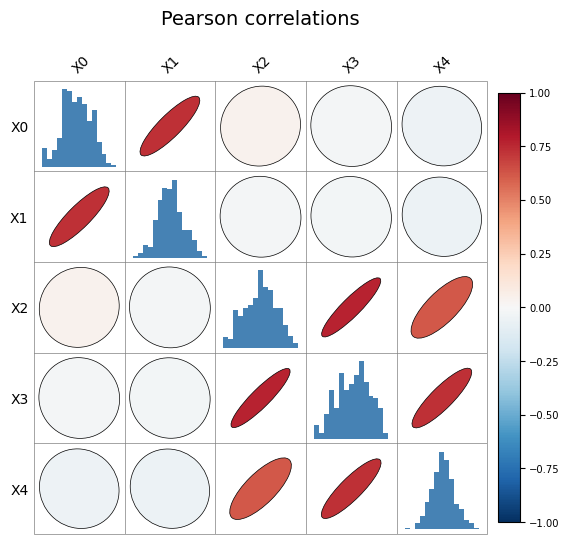

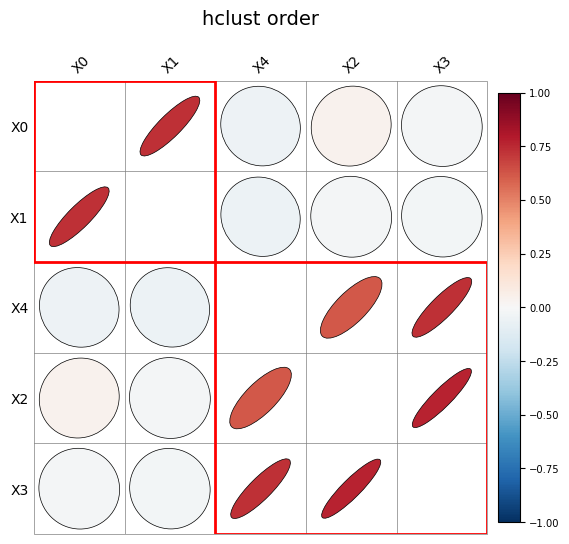

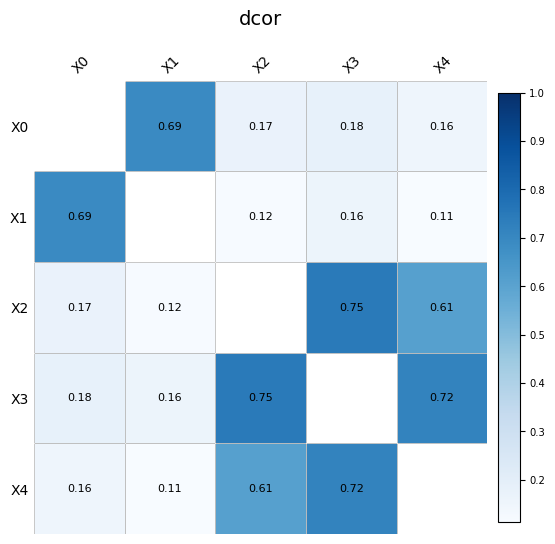

In [25]:
from causalts.plotting import corrplot, compute_association_matrix

# Pearson association on the shared dataset
fig, ax, mat = corrplot(df_a, metric="pearson", method="ellipse",
                        title="Pearson correlations")
plt.show()

# Hierarchical ordering + rectangles around clusters (on a precomputed matrix)
corr_a = df_a.corr()
fig, ax, _ = corrplot(corr_a, order="hclust", addrect=2, rect_col="red",
                      method="ellipse", title="hclust order")
plt.show()

# Distance correlation: precompute once, then visualize
dcor_a = compute_association_matrix(df_a, metric="dcor")
fig, ax, _ = corrplot(dcor_a, is_corr=False, method="color", add_coef=True,
                      cmap="Blues", title="dcor")
plt.show()

<a id="7-synthetic-data"></a>
# 7. Synthetic Data

```python
from causalts.synthetic_data.synthetic_datasets import (
    SCPGraphGenerator, load_dataset, lorenz96, topology_scp, ercot_weather,
)
```

## `load_dataset`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.synthetic_data.<strong>load_dataset</strong>(<em>name, seed=42, T=300, **kwargs</em>)
</div>

Load a named synthetic dataset. Returns a dict with `df`, `ground_truth`, `max_lag`, `var_names`.

Available names: `'ex1'` (5-Node Nonlinear System, d=5), `'ex2'` (6-Node Linear VAR, d=6), `'ex3'` (Cascade Network, d=11), `'henon'` (Hénon Chain), `'ercot_weather'` (d=16, calibrated weather benchmark), plus topology variants: `'scale_free'`, `'erdos_renyi'`, `'small_world'` (each with `'_dense'` variant).

---

## `lorenz96`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.synthetic_data.<strong>lorenz96</strong>(<em>N=10, T=2000, F=8.0, dt=0.01, seed=42</em>)
</div>

Lorenz-96 chaotic dynamical system with multiplicative (non-additive) coupling. Used as a challenging benchmark where linear and additive assumptions fail. Returns dict with `df`, `ground_truth`, `max_lag=1`.

---

## `check_linearity`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.utils.<strong>check_linearity</strong>(<em>df, max_lag=3, alpha=0.05</em>)
</div>

Run Ramsey RESET test across all variable pairs to detect nonlinearity. If no significant nonlinearity is found, `ParCorrGPU` is optimal. Returns a dict with `results` (list of per-pair test outcomes) and `any_nonlinear` (bool).

```python
from causalts.utils.linearity import check_linearity
result = check_linearity(df, max_lag=3)
if not result["any_nonlinear"]:
    print("Data appears linear — use ParCorrGPU")
```

---

<a id="scpgraphgenerator"></a>
## `SCPGraphGenerator`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
<em>class</em> causalts.synthetic_data.<strong>SCPGraphGenerator</strong>(<em>n_vars, max_lag=5, density='sparse', enforce_stationary=True, max_spectral_radius=0.85, dependency_funcs=('linear', 'quadratic', 'cubic', 'sin', 'cos')</em>)
</div>

Generate random Structural Causal Process (SCP) graphs for benchmarking.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>n_vars</strong> : <em>int</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Number of variables.</dd>
<dt><strong>max_lag</strong> : <em>int, default=5</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Maximum lag.</dd>
<dt><strong>density</strong> : <em>str, default='sparse'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'sparse'</code> or <code>'dense'</code>.</dd>
<dt><strong>enforce_stationary</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Ensure VAR stability.</dd>
<dt><strong>max_spectral_radius</strong> : <em>float, default=0.85</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Maximum spectral radius.</dd>
<dt><strong>dependency_funcs</strong> : <em>tuple, default=all</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Nonlinear function types to include.</dd>
</dl>
</div>

---

<a id="sample"></a>
## `.sample`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
gen.<strong>sample</strong>(<em>seed, T=3000, n_links=None, max_tries=200</em>)
</div>

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>seed</strong> : <em>int</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Random seed.</dd>
<dt><strong>T</strong> : <em>int, default=3000</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Number of time steps.</dd>
<dt><strong>n_links</strong> : <em>int, default=None</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Target number of links (<code>None</code> = auto from density).</dd>
<dt><strong>max_tries</strong> : <em>int, default=200</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Max attempts for stable graph.</dd>
</dl>
</div>

**Returns dict:** `df`, `ground_truth`, `var_names`, `max_lag`, `links`, `meta`

Variables: ['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9']
True edges: 22
Data shape: (500, 10)


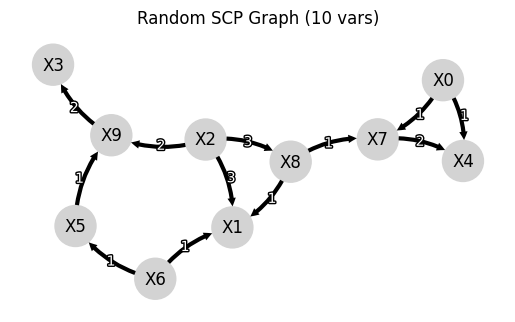

In [26]:
gen = SCPGraphGenerator(n_vars=10, max_lag=3, density="sparse")
result = gen.sample(seed=123, T=500)

print(f"Variables: {result['var_names']}")
print(f"True edges: {int(result['ground_truth'].sum())}")
print(f"Data shape: {result['df'].shape}")

tp.plot_graph(
    result["ground_truth"], var_names=result["var_names"], arrow_linewidth=3,
    node_size=0.2, show_colorbar=False, node_layout="neato",
)
plt.title("Random SCP Graph (10 vars)")
plt.show()

---

<a id="8-evaluation"></a>
# 8. Evaluation

```python
from causalts.utils import evaluate_graph
```

<a id="evaluate_graph"></a>
## `evaluate_graph`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.utils.<strong>evaluate_graph</strong>(<em>G_est, G_true, exclude_self_loops=False</em>)
</div>

Compare estimated graph to ground truth. Both inputs have shape `(d, d, max_lag+1)` where `graph[i, j, tau]=1` means i(t-tau) -> j(t).

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>G_est</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Estimated graph (d, d, tau+1).</dd>
<dt><strong>G_true</strong> : <em>ndarray</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Ground truth graph (d, d, tau+1).</dd>
<dt><strong>exclude_self_loops</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Exclude autodependencies at all lags.</dd>
</dl>

**Returns dict:**

<dl style="margin-left: 8px;">
<dt><strong>TPR</strong> / <strong>Recall</strong></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">True positive rate (per-lag).</dd>
<dt><strong>FPR</strong></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">False positive rate (per-lag).</dd>
<dt><strong>Precision</strong></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Per-lag precision.</dd>
<dt><strong>F1</strong></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Per-lag F1 score.</dd>
<dt><strong>SHD</strong></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Structural Hamming Distance.</dd>
<dt><strong>Pair_TPR</strong>, <strong>Pair_Precision</strong>, <strong>Pair_F1</strong>, <strong>Pair_SHD</strong></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Pair-level variants.</dd>
</dl>
</div>

In [19]:
metrics = evaluate_graph(graph_b, true_b)
for k, v in metrics.items():
    print(f"{k:<16} {v:.3f}" if isinstance(v, float) else f"{k:<16} {v}")

TPR              0.929
FPR              0.002
Precision        0.963
F1               0.945
SHD              3
SHD_pair         2
F1_pair          0.938
TPR_pair         0.882
FPR_pair         0.000
Precision_pair   1.000
TP               26
FP               1
FN               2
TN               444



<a id="9-effect-estimation"></a>
# 9. Effect Estimation (DoWhy)

```python
from causalts.effects import (
    estimate_effect, fit_scm, counterfactual, attribute_anomaly,
    wrap_graph, graph_to_networkx, make_lagged_df,
)
```

Optional integration with [DoWhy](https://www.pywhy.org/dowhy/) for causal effect estimation, counterfactual analysis, and root cause attribution. Requires `pip install dowhy>=0.11` (or `pip install causalts[dowhy]`).

Every built-in algorithm (`run_cdnots`, `run_cdnots_plus`, `SYPI`, `run_cdnots_gated`,
`run_stability_selection`, `run_cedar`, `run_lucid`, ...) returns a `CausalResult`
subclass with these methods bound automatically: `res.estimate_effect(...)`.
`wrap_graph` is only needed for a **third-party algorithm that returns a plain
array** instead of a result object.

---

<a id="estimate_effect"></a>
## `estimate_effect`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
cg_obj.<strong>estimate_effect</strong>(<em>treatment, outcome, treatment_lag=1, method='backdoor.linear_regression', confidence_intervals=True, n_bootstraps=100</em>)
</div>

Estimate the average causal effect of `treatment(t-lag)` on `outcome(t)` using DoWhy's identification and estimation pipeline with the discovered graph as the identifying assumption.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>treatment</strong> : <em>str</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Treatment variable name (e.g. "PKC").</dd>
<dt><strong>outcome</strong> : <em>str</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Outcome variable name (e.g. "Mek").</dd>
<dt><strong>treatment_lag</strong> : <em>int, default=1</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Which lag of the treatment to use.</dd>
<dt><strong>method</strong> : <em>str, default='backdoor.linear_regression'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">DoWhy estimation method. Also: <code>'backdoor.propensity_score_matching'</code>.</dd>
<dt><strong>confidence_intervals</strong> : <em>bool, default=True</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Compute bootstrap confidence intervals.</dd>
<dt><strong>n_bootstraps</strong> : <em>int, default=100</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Bootstrap replications for CIs.</dd>
</dl>

**Returns:** `dowhy.CausalEstimate` with `.value`, `.get_confidence_intervals()`, `.test_stat_significance()`
</div>

> **Note:** The estimate is only as good as the discovered graph. Missing edges produce omitted-variable bias; spurious edges produce inflated estimates.

---

<a id="fit_scm"></a>
## `fit_scm`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
cg_obj.<strong>fit_scm</strong>(<em>mechanism_type='auto', force=False</em>)
</div>

Fit a Structural Causal Model (InvertibleStructuralCausalModel) to the discovered graph. Required for counterfactual and root cause analysis.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>mechanism_type</strong> : <em>str, default='auto'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'auto'</code> (DoWhy auto-selects), <code>'linear'</code> (fast, interpretable), <code>'gp'</code> (Gaussian Process, nonlinear).</dd>
<dt><strong>force</strong> : <em>bool, default=False</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">If True, refit even if cached.</dd>
</dl>

**Returns:** `(scm, dag, lagged_df)` — the fitted SCM, the NetworkX DAG, and the lag-embedded DataFrame.
</div>

> **Caching:** Results are cached on the graph object. Repeated calls with the same `mechanism_type` are free.

---

<a id="counterfactual_method"></a>
## `counterfactual`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
cg_obj.<strong>counterfactual</strong>(<em>intervention, target, mechanism_type='auto'</em>)
</div>

Estimate counterfactual values: "What would `target(t)` have been if we had intervened on a parent?"

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>intervention</strong> : <em>dict</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Maps node names to clamped values. E.g. <code>{"PKC_lag1": 0.0}</code> = do(PKC(t-1) := 0).</dd>
<dt><strong>target</strong> : <em>str</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Current-time variable to query.</dd>
<dt><strong>mechanism_type</strong> : <em>str, default='auto'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Passed to <code>fit_scm</code> if SCM not already cached.</dd>
</dl>

**Returns:** `pd.Series` of counterfactual values, one per time step.
</div>

---

<a id="attribute_anomaly_method"></a>
## `attribute_anomaly`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
cg_obj.<strong>attribute_anomaly</strong>(<em>anomaly, target, mechanism_type='auto', n_samples=2000</em>)
</div>

Attribute an anomaly in `target` to its upstream causes via Shapley-based attribution (Janzing et al. 2019).

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>anomaly</strong> : <em>pd.Series or pd.DataFrame</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Anomalous observation(s). Must have columns matching <code>lagged_df</code>.</dd>
<dt><strong>target</strong> : <em>str</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Variable to explain (current-time node).</dd>
<dt><strong>mechanism_type</strong> : <em>str, default='auto'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Passed to <code>fit_scm</code> if not cached.</dd>
<dt><strong>n_samples</strong> : <em>int, default=2000</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Monte Carlo samples for Shapley estimation.</dd>
</dl>

**Returns:** `pd.DataFrame` with columns `[node, variable, lag, mean_attribution]`, sorted by |attribution| descending.
</div>

---

<a id="wrap_graph_fn"></a>
## `wrap_graph`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.effects.<strong>wrap_graph</strong>(<em>graph, df, var_names=None</em>)
</div>

Wrap a plain 3D NumPy graph (from GRACE or `run_stability_selection`) with bridge methods.

```python
from causalts.effects import wrap_graph
res = run_cdnots_gated(df, max_lag=3)
cg = wrap_graph(res.cg_tig, df)
cg.estimate_effect("PKC", "Mek", treatment_lag=1)  # works identically
```

---

<a id="graph_to_networkx_fn"></a>
## `graph_to_networkx`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.effects.<strong>graph_to_networkx</strong>(<em>graph, var_names=None, mode='full', include_c=False, cycle_resolution='error'</em>)
</div>

Convert a 3D causal-ts graph to a NetworkX DiGraph for use with any DoWhy function directly.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>graph</strong> : <em>ndarray (d, d, max_lag+1)</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Discovered causal graph.</dd>
<dt><strong>mode</strong> : <em>str, default='full'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'full'</code>: all d*(max_lag+1) nodes — for effect estimation. <code>'summary'</code>: lag nodes as roots — for GCM fitting.</dd>
<dt><strong>cycle_resolution</strong> : <em>str, default='error'</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;"><code>'error'</code>: raise on cycles. <code>'drop'</code>: silently drop the second direction. <code>'first'</code>: keep lexicographically-first.</dd>
</dl>

**Returns:** `networkx.DiGraph` with time-expanded nodes (e.g. "PKC", "PKC_lag1", "PKC_lag2", ...)
</div>

---

<a id="10-tigramite-effects"></a>
# 10. Effect Estimation (Tigramite)

```python
from causalts.effects.tigramite_effects import TigramiteEffects, pathwise_effects
```

Optional integration with [tigramite](https://github.com/jakobrunge/tigramite) for causal effect estimation using **Wright's path-tracing method**. Requires `pip install tigramite`.

| | DoWhy bridge | Tigramite bridge |
|---|---|---|
| Method | Backdoor criterion + regression | Wright path coefficients |
| Effect type | ATE (average treatment effect) | Total, direct, mediated |
| Graph handling | Lag-embeds to DAG | Works on time-series graph directly |
| Mediators | Not separated | Identified and quantified |
| Best for | Observational ATE with confounders | Path decomposition, mediation analysis |

<a id="tigramite-effects-class"></a>
## `TigramiteEffects`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.effects.tigramite_effects.<strong>TigramiteEffects</strong>(<em>graph, df, X_var, X_lag, Y_var, var_names=None</em>)
</div>

Estimates total, direct, and mediated causal effects by fitting Wright path-coefficient regressions along all directed paths in the time-series graph.

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Parameters:**

<dl style="margin-left: 8px;">
<dt><strong>graph</strong> : <em>ndarray (d, d, max_lag+1)</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Binary causal graph — use <code>result.cg_tig</code> from <code>run_cdnots</code>, or the first return of <code>run_cdnots_gated</code>.</dd>
<dt><strong>df</strong> : <em>DataFrame (T, d)</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Original time-series data (not lag-embedded).</dd>
<dt><strong>X_var</strong> : <em>str or int</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Treatment variable name or index.</dd>
<dt><strong>X_lag</strong> : <em>int</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Lag of the treatment: <code>X_lag=1</code> means <code>X_var(t-1)</code>.</dd>
<dt><strong>Y_var</strong> : <em>str or int</em></dt>
<dd style="margin-left: 24px; margin-bottom: 8px;">Outcome variable (always at current time <code>t</code>).</dd>
</dl>

**Methods:**
- `.fit(method='parents')` — fit path-coefficient regressions; call before querying
- `.total_effect()` → float — sum over all directed paths from X to Y
- `.direct_effect()` → float — direct edge only, excluding mediated paths
- `.mediated_effect(through=None)` → float — effect through specified mediators
- `.get_mediators()` → list of (var_name, lag) — intermediate nodes on causal paths
- `.optimal_adjustment_set()` → list — optimal covariate adjustment set
- `.summary()` → dict — total, direct, indirect, mediators in one call
</div>


In [17]:
from causalts.effects.tigramite_effects import TigramiteEffects, pathwise_effects

# PKC -> P38, lag=2: has BOTH a direct edge (PKC(t-2)->P38) AND an indirect
# path PKC(t-2)->PKA(t-1)->P38(t), so direct effect != total effect.
# Use true_b (ground truth) for a reproducible demo.
eff = TigramiteEffects(
    graph=true_b,
    df=df_b,
    X_var="PKC",
    X_lag=2,
    Y_var="P38",
    var_names=names_b,
)
eff.fit()

s = eff.summary()
print(f"Treatment : {s['treatment']}(t-{s['treatment_lag']})")
print(f"Outcome   : {s['outcome']}")
print(f"Total     : {s['total']:+.4f}")
print(f"Direct    : {s['direct']:+.4f}  (PKC(t-2)->P38 direct edge)")
print(f"Indirect  : {s['indirect']:+.4f}  (via PKA)")
print(f"Mediators : {s['mediators']}")


Treatment : PKC(t-2)
Outcome   : P38
Total     : +0.6661
Direct    : +0.5086  (PKC(t-2)->P38 direct edge)
Indirect  : +0.1575  (via PKA)
Mediators : [('PKA', np.int64(1))]


<a id="pathwise-effects"></a>
## `pathwise_effects`

<div style="background: #FDF5E6; padding: 12px 16px; border-radius: 4px; margin: 8px 0; font-family: 'SFMono-Regular', Consolas, monospace; font-size: 0.85em; line-height: 1.8;">
causalts.effects.tigramite_effects.<strong>pathwise_effects</strong>(<em>graph, df, X_var, Y_var, var_names=None, max_path_lag=None, method='parents'</em>)
</div>

Enumerate **all** directed causal paths from `X_var` to `Y_var` in the graph and quantify the effect along each one. Useful when multiple pathways exist at different lag horizons (e.g. a direct lag-1 edge and an indirect lag-3 path through a mediator).

<div style="border-left: 3px solid #ddd; padding-left: 16px; margin: 12px 0;">

**Returns** a dict with:
- `'paths'` — list of dicts, each with `'route'` (human-readable), `'nodes'`, `'edge_lags'`, `'total_lag'`
- `'by_lag'` — dict mapping total_lag → `{'effect': float, 'paths': [...]}`
- `'cumulative'` — sum of effects across all lag horizons
- `'shares'` — dict mapping lag → fraction of cumulative absolute effect
</div>


In [18]:
# PKC -> Erk has 4 directed paths at lags 2,3,4,5 through different routes.
result_pw = pathwise_effects(
    graph=true_b,
    df=df_b,
    X_var="PKC",
    Y_var="Erk",
    var_names=names_b,
)

print(f"Paths found: {len(result_pw['paths'])}")
print(f"Cumulative effect: {result_pw['cumulative']:+.4f}\n")
print("Per-lag breakdown:")
for lag, info in sorted(result_pw['by_lag'].items()):
    routes = ' | '.join(p['route'] for p in info['paths'])
    share  = result_pw['shares'][lag]
    print(f"  lag {lag}: effect={info['effect']:+.4f}  share={share:.1%}  [{routes}]")


Paths found: 5
Cumulative effect: +0.2545

Per-lag breakdown:
  lag 2: effect=-0.1226  share=24.5%  [PKC → PKA → Erk]
  lag 3: effect=+0.0426  share=8.5%  [PKC → Mek → Erk]
  lag 4: effect=+0.1702  share=34.1%  [PKC → PKA → Mek → Erk]
  lag 5: effect=+0.1417  share=28.4%  [PKC → Raf → Mek → Erk]
  lag 7: effect=+0.0226  share=4.5%  [PKC → PKA → Raf → Mek → Erk]
